# 03  -  FF2: Wachstums-Hotspots (Growth Hotspots)

**Forschungsfrage:** Welche Zählstellen zeigen den stärksten Wachstumstrend (2020-2025)? Bei Fortschreibung des aktuellen Trends: Welche Stationen werden ihr Aufkommen innerhalb von 5 Jahren verdoppeln? Wo soll die Stadt präventive Kapazitätserweiterung priorisieren?

**Entscheidungslogik (CPA Step 5 — Make data-driven decisions):**
- **Ergebnis A:** Starkes Wachstum konzentriert sich auf bestimmte Korridore → Präventive Kapazitätserweiterung einplanen
- **Ergebnis B:** Wachstum ist stadtweit gleichmässig → Netzweite Standards anheben statt Einzelstandorte priorisieren

(Die statistische Auswertung selbst — Regression, CAGR, Signifikanz — entspricht CPA Step 3 "Analyse data". Das Notebook deckt also Steps 2-5 ab; die Entscheidungsregel oben legt vorab fest, wie das Step-3-Ergebnis in Step 5 übersetzt wird.)

**Methodik (Überblick):**
1. Nur konsistente Stationen verwenden (≥60% Abdeckung über alle Jahre)
2. Jahrestotale pro Station berechnen, partielle Jahre (v.a. 2025) annualisieren
3. Saisonale Verzerrung prüfen, ggf. 2025 ausschliessen
4. Lineare Regression + CAGR pro Station: Wachstumsrate, R², Signifikanz
5. Trendextrapolation und Verdopplungsprognose (5-Jahres-Horizont)
6. Signifikanz- und Konzentrations-Analyse (CPA-Ergebnis A vs. B)
7. **Prioritätsscore** pro Station (Wachstum + Konfidenz + Volumen + Dringlichkeit)
8. **Management-Entscheidung** mit konkreter Station-Priorisierung

Die gesamte Analyse **inklusive Data Cleaning**, Score und Management-Empfehlung liegt in diesem einen Notebook - es gibt keine Vor- oder Folge-Notebooks für FF2.

**Datengrundlage:** die rohen Jahres-CSVs (`20xx_verkehrszaehlungen_werte_fussgaenger_velo.csv`) sowie `standorte_velo_fuss.json` aus `data/` - durch manuelles Entpacken von `data/data_bundle.zip` bereitgestellt.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 6)

print("Libraries loaded.")


Libraries loaded.


---
## Schritt 1: Rohdaten laden und bereinigen

Die Bereinigung lief früher in einem separaten Notebook 02. Sie ist hier nun
**direkt integriert** (wie bei FF1 und FF3), damit FF2 eigenständig läuft.

Gelesen werden die rohen 15-Minuten-Jahres-CSVs aus `data/` (manuell entpackt
aus `data/data_bundle.zip`). Bereinigungsschritte:

1. Spalten umbenennen, Jahres-CSVs zusammenführen
2. Nur Velo-Stationen behalten (Fussgänger-Zählstellen verwerfen)
3. Datetime parsen, Duplikate entfernen, Zeitkomponenten ableiten
4. `velo_total` berechnen (uni-/bi-direktionale Stationen unterscheiden)
5. Lange Null-Serien > 6 h als Sensor-Ausfall markieren → NaN
6. Negative Werte korrigieren, Wertebereiche validieren
7. `is_consistent`-Flag setzen (≥60 % Abdeckung je Jahr) — kritisch für die Trendanalyse
8. Stationsmetadaten inkl. Standortname (`bezeichnung`) aufbauen

Das Ergebnis ist ein bereinigter 15-Min-DataFrame `df` plus `meta` (Stationsinfos).

In [2]:
import glob
import os

# Cleaning-Log  -  jede Bereinigungsentscheidung wird protokolliert
cleaning_log = []

def log_step(step, description, rows_affected, detail=""):
    cleaning_log.append({
        "step": step,
        "description": description,
        "rows_affected": rows_affected,
        "detail": detail,
    })
    print(f"[Step {step}] {description}  -  {rows_affected:,} rows affected. {detail}")

In [3]:
# Load and concatenate all year files
files = sorted(glob.glob("../../data/20*_verkehrszaehlungen_werte_fussgaenger_velo.csv"))
print(f"Found {len(files)} files:")

dfs = []
for f in files:
    tmp = pd.read_csv(f)
    year = os.path.basename(f)[:4]
    print(f"  {os.path.basename(f)}: {len(tmp):>10,} rows, {tmp['FK_STANDORT'].nunique()} stations")
    dfs.append(tmp)

df_raw = pd.concat(dfs, ignore_index=True)
print(f"\nCombined: {len(df_raw):,} rows, {df_raw['FK_STANDORT'].nunique()} unique stations")
print(f"Columns: {df_raw.columns.tolist()}")
print(f"\nNull counts:\n{df_raw.isnull().sum()}")
print(f"\nDtypes:\n{df_raw.dtypes}")

Found 6 files:


  2020_verkehrszaehlungen_werte_fussgaenger_velo.csv:  1,257,695 rows, 49 stations


  2021_verkehrszaehlungen_werte_fussgaenger_velo.csv:  1,178,570 rows, 46 stations


  2022_verkehrszaehlungen_werte_fussgaenger_velo.csv:  1,189,238 rows, 47 stations
  2023_verkehrszaehlungen_werte_fussgaenger_velo.csv:    949,660 rows, 46 stations


  2024_verkehrszaehlungen_werte_fussgaenger_velo.csv:    918,683 rows, 27 stations
  2025_verkehrszaehlungen_werte_fussgaenger_velo.csv:    853,565 rows, 28 stations



Combined: 6,347,411 rows, 83 unique stations
Columns: ['FK_STANDORT', 'DATUM', 'VELO_IN', 'VELO_OUT', 'FUSS_IN', 'FUSS_OUT', 'OST', 'NORD']

Null counts:
FK_STANDORT          0
DATUM                0
VELO_IN        1847736
VELO_OUT       2420725
FUSS_IN        4493339
FUSS_OUT       4493339
OST                  0
NORD                 0
dtype: int64

Dtypes:
FK_STANDORT      int64
DATUM              str
VELO_IN        float64
VELO_OUT       float64
FUSS_IN        float64
FUSS_OUT       float64
OST              int64
NORD             int64
dtype: object


In [4]:
# Rename columns to clean, descriptive names
df = df_raw.rename(columns={
    "FK_STANDORT": "station_id",
    "DATUM": "datetime",
    "VELO_IN": "velo_in",
    "VELO_OUT": "velo_out",
    "FUSS_IN": "fuss_in",
    "FUSS_OUT": "fuss_out",
    "OST": "easting",   # LV95 coordinates
    "NORD": "northing",
})

log_step("1.1", "Loaded and concatenated yearly CSVs, renamed columns", len(df))

[Step 1.1] Loaded and concatenated yearly CSVs, renamed columns  -  6,347,411 rows affected. 


In [5]:
# Identify station types: velo-only, fuss-only, both
has_velo = df.groupby("station_id")["velo_in"].apply(lambda x: x.notnull().any())
has_fuss = df.groupby("station_id")["fuss_in"].apply(lambda x: x.notnull().any())

velo_stations = has_velo[has_velo].index
fuss_only_stations = has_fuss[~has_velo & has_fuss].index

print(f"Stations with velo data: {len(velo_stations)}")
print(f"Stations with fuss only: {len(fuss_only_stations)} (will be dropped)")
print(f"Stations with both:      {(has_velo & has_fuss).sum()}")

# Filter to velo stations only
n_before = len(df)
df = df[df["station_id"].isin(velo_stations)].copy()

# Drop pedestrian columns  -  not relevant for our questions
df = df.drop(columns=["fuss_in", "fuss_out"])

log_step("1.2", "Filtered to velo-only stations, dropped fuss columns",
         n_before - len(df), f"Kept {df['station_id'].nunique()} stations")

Stations with velo data: 46
Stations with fuss only: 37 (will be dropped)
Stations with both:      2
[Step 1.2] Filtered to velo-only stations, dropped fuss columns  -  1,847,736 rows affected. Kept 46 stations


In [6]:
# Parse datetime
df["datetime"] = pd.to_datetime(df["datetime"], format="%Y-%m-%dT%H:%M")

print(f"Date range: {df['datetime'].min()} to {df['datetime'].max()}")

# Check for duplicates (same station + same timestamp should not exist)
n_dupes = df.duplicated(subset=["station_id", "datetime"]).sum()
print(f"\nDuplicate (station_id, datetime) pairs: {n_dupes}")

if n_dupes > 0:
    # Inspect before dropping
    dupes = df[df.duplicated(subset=["station_id", "datetime"], keep=False)]
    print(dupes.sort_values(["station_id", "datetime"]).head(10))
    df = df.drop_duplicates(subset=["station_id", "datetime"], keep="first")
    log_step("1.3", "Removed duplicate station+datetime rows", n_dupes)
else:
    log_step("1.3", "Parsed datetime, no duplicates found", 0)

# Extract time components (needed throughout)
df["year"] = df["datetime"].dt.year
df["month"] = df["datetime"].dt.month
df["hour"] = df["datetime"].dt.hour
df["weekday"] = df["datetime"].dt.weekday  # 0=Mon, 6=Sun

df.head()

Date range: 2020-01-01 00:00:00 to 2025-12-31 23:45:00

Duplicate (station_id, datetime) pairs: 512


         station_id            datetime  velo_in  velo_out  easting  northing
1021590          60 2020-10-25 02:00:00      0.0       0.0  2682731   1247708
1021591          60 2020-10-25 02:00:00      1.0       0.0  2682731   1247708
1021661          60 2020-10-25 02:15:00      1.0       0.0  2682731   1247708
1021662          60 2020-10-25 02:15:00      2.0       0.0  2682731   1247708
1021796          60 2020-10-25 02:30:00      0.0       0.0  2682731   1247708
1021797          60 2020-10-25 02:30:00      0.0       0.0  2682731   1247708
1021804          60 2020-10-25 02:45:00      1.0       0.0  2682731   1247708
1021805          60 2020-10-25 02:45:00      0.0       0.0  2682731   1247708
2241750          60 2021-10-31 02:00:00      1.0       0.0  2682731   1247708
2241751          60 2021-10-31 02:00:00      0.0       6.0  2682731   1247708
[Step 1.3] Removed duplicate station+datetime rows  -  512 rows affected. 


,station_id,datetime,velo_in,velo_out,easting,northing,year,month,hour,weekday
0,3927,2020-01-01,1.0,1.0,2682873,1245891,2020,1,0,2
1,2977,2020-01-01,1.0,NaN,2682681,1250570,2020,1,0,2
2,3923,2020-01-01,0.0,0.0,2681385,1247736,2020,1,0,2
3,2979,2020-01-01,0.0,0.0,2681858,1251991,2020,1,0,2
4,60,2020-01-01,0.0,0.0,2682731,1247708,2020,1,0,2


In [7]:
# Classify stations as uni- or bi-directional
station_direction = df.groupby("station_id").agg(
    has_in=("velo_in", lambda x: x.notnull().any()),
    has_out=("velo_out", lambda x: x.notnull().any()),
    pct_out_null=("velo_out", lambda x: x.isnull().mean() * 100),
).reset_index()

uni_directional = station_direction[~station_direction["has_out"]]["station_id"].values
bi_directional = station_direction[station_direction["has_out"]]["station_id"].values

print(f"Bi-directional stations (IN + OUT):  {len(bi_directional)}")
print(f"Uni-directional stations (IN only):  {len(uni_directional)}")
print(f"  Uni-directional IDs: {sorted(uni_directional)}")

# Compute total volume
# Bi-directional: total = in + out
# Uni-directional: total = in (already represents total through-traffic)
df["velo_total"] = np.where(
    df["station_id"].isin(uni_directional),
    df["velo_in"],
    df["velo_in"].fillna(0) + df["velo_out"].fillna(0),
)

# Flag direction type for reference
df["is_bidirectional"] = df["station_id"].isin(bi_directional)

log_step("1.4", "Computed velo_total (uni/bi-directional aware)", 0,
         f"{len(uni_directional)} uni-directional, {len(bi_directional)} bi-directional")

Bi-directional stations (IN + OUT):  39
Uni-directional stations (IN only):  7
  Uni-directional IDs: [np.int64(62), np.int64(2977), np.int64(2982), np.int64(3008), np.int64(4258), np.int64(4267), np.int64(4272)]
[Step 1.4] Computed velo_total (uni/bi-directional aware)  -  0 rows affected. 7 uni-directional, 39 bi-directional


In [8]:
ZERO_RUN_THRESHOLD = 24  # 24 × 15min = 6 hours

def flag_suspicious_zeros(group):
    """Flag zero-runs longer than threshold as sensor failure."""
    is_zero = group["velo_total"] == 0
    # Create groups of consecutive equal values
    groups = is_zero.ne(is_zero.shift()).cumsum()
    consecutive_len = is_zero.groupby(groups).transform("sum")
    return is_zero & (consecutive_len > ZERO_RUN_THRESHOLD)

# Apply per station (zero-runs should be detected within each station)
df["sensor_failure"] = df.groupby("station_id", group_keys=False).apply(flag_suspicious_zeros)

n_flagged = df["sensor_failure"].sum()
n_stations_affected = df[df["sensor_failure"]]["station_id"].nunique()

print(f"Rows flagged as sensor failure: {n_flagged:,}")
print(f"Stations affected: {n_stations_affected}")

# Show worst affected stations
failure_by_station = df[df["sensor_failure"]].groupby("station_id").size().sort_values(ascending=False)
print(f"\nTop 10 affected stations:")
print(failure_by_station.head(10))

# Set sensor failures to NaN
df.loc[df["sensor_failure"], ["velo_in", "velo_out", "velo_total"]] = np.nan

log_step("1.5", "Flagged long zero-runs as sensor failure → NaN", n_flagged,
         f"{n_stations_affected} stations affected, threshold={ZERO_RUN_THRESHOLD} intervals (6h)")

Rows flagged as sensor failure: 68,615
Stations affected: 27

Top 10 affected stations:
station_id
4257    29104
3008     7322
4255     5478
2978     4670
1692     4247
4269     3932
3927     3778
3924     2417
53       1982
5002     1633
dtype: int64
[Step 1.5] Flagged long zero-runs as sensor failure → NaN  -  68,615 rows affected. 27 stations affected, threshold=24 intervals (6h)


In [9]:
# Negative values are physically impossible for counts
n_negative_in = (df["velo_in"] < 0).sum()
n_negative_out = (df["velo_out"] < 0).sum()
print(f"Negative velo_in:  {n_negative_in}")
print(f"Negative velo_out: {n_negative_out}")

if n_negative_in + n_negative_out > 0:
    df.loc[df["velo_in"] < 0, "velo_in"] = np.nan
    df.loc[df["velo_out"] < 0, "velo_out"] = np.nan
    # Recompute total
    df["velo_total"] = np.where(
        df["station_id"].isin(uni_directional),
        df["velo_in"],
        df["velo_in"].fillna(0) + df["velo_out"].fillna(0),
    )

# Sanity check: max value per 15-min interval
print(f"\nvelo_total range: {df['velo_total'].min():.0f} - {df['velo_total'].max():.0f}")
print(f"99.9th percentile: {df['velo_total'].quantile(0.999):.0f}")

# Flag extreme values (> 99.9th percentile) for review but don't remove
p999 = df["velo_total"].quantile(0.999)
n_extreme = (df["velo_total"] > p999).sum()
print(f"Rows above 99.9th percentile ({p999:.0f}): {n_extreme}")

log_step("1.6", "Validated ranges, set negative values to NaN", n_negative_in + n_negative_out)

Negative velo_in:  0
Negative velo_out: 0

velo_total range: 0 - 1086
99.9th percentile: 155
Rows above 99.9th percentile (155): 4345
[Step 1.6] Validated ranges, set negative values to NaN  -  0 rows affected. 


Stations with ≥60% coverage ALL years 2020-2024: 6
Stations with ≥60% coverage 2022-2024:           12

Note: Zürich replaced many older stations with new ones around 2022-2023.
For FF2 growth analysis, the 2022-2024 window is more practical.


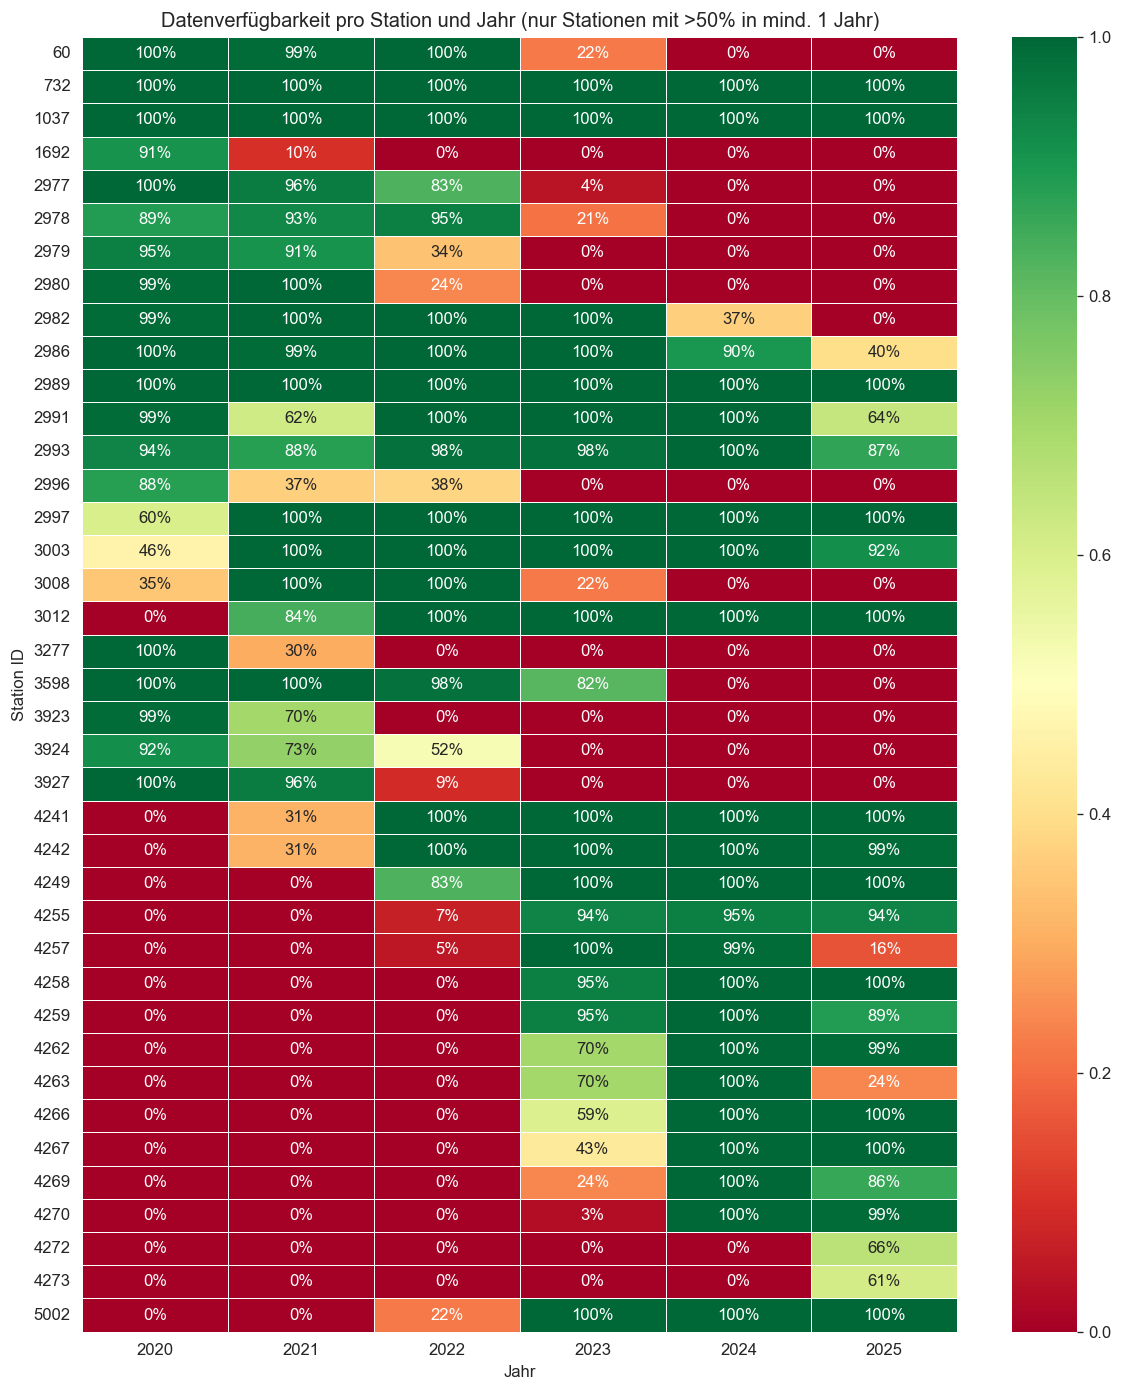

[Step 1.7] Identified stations with consistent multi-year coverage  -  0 rows affected. 6 full-span (2020-24), 12 recent (2022-24)


In [10]:
# For each station: which years have substantial data?
# "Substantial" = at least 60% of expected rows for that year (non-NaN velo_total)
COVERAGE_THRESHOLD = 0.60
INTERVALS_PER_YEAR = 365.25 * 24 * 4  # ~35,064

station_year = df.groupby(["station_id", "year"]).agg(
    total_rows=("velo_total", "size"),
    valid_rows=("velo_total", "count"),  # non-NaN
).reset_index()
station_year["coverage"] = station_year["valid_rows"] / INTERVALS_PER_YEAR

# Pivot for visualization
coverage_pivot = station_year.pivot(index="station_id", columns="year", values="coverage").fillna(0)

# The Zürich station network changed significantly: many old stations decommissioned,
# many new ones added from 2022+. We check two windows:
# - Full span 2020-2024 (strict, for long-term trend)
# - Recent span 2022-2024 (more stations, for shorter trend)
full_years = [2020, 2021, 2022, 2023, 2024]
recent_years = [2022, 2023, 2024]

full_cols = [y for y in full_years if y in coverage_pivot.columns]
recent_cols = [y for y in recent_years if y in coverage_pivot.columns]

consistent_full = (coverage_pivot[full_cols] >= COVERAGE_THRESHOLD).all(axis=1)
consistent_recent = (coverage_pivot[recent_cols] >= COVERAGE_THRESHOLD).all(axis=1)

consistent_stations_full = consistent_full[consistent_full].index.tolist()
consistent_stations_recent = consistent_recent[consistent_recent].index.tolist()
# Use the broader set (recent) as default
consistent_stations = consistent_stations_recent

print(f"Stations with ≥{COVERAGE_THRESHOLD*100:.0f}% coverage ALL years 2020-2024: {len(consistent_stations_full)}")
print(f"Stations with ≥{COVERAGE_THRESHOLD*100:.0f}% coverage 2022-2024:           {len(consistent_stations_recent)}")
print(f"\nNote: Zürich replaced many older stations with new ones around 2022-2023.")
print(f"For FF2 growth analysis, the 2022-2024 window is more practical.")

# Visualize coverage matrix (only stations with >50% in any year)
has_data = (coverage_pivot > 0.5).any(axis=1)
plot_data = coverage_pivot[has_data]

fig, ax = plt.subplots(figsize=(10, max(6, len(plot_data) * 0.3)))
sns.heatmap(
    plot_data.round(2),
    annot=True, fmt=".0%", cmap="RdYlGn", vmin=0, vmax=1,
    linewidths=0.5, ax=ax,
)
ax.set_title("Datenverfügbarkeit pro Station und Jahr (nur Stationen mit >50% in mind. 1 Jahr)")
ax.set_ylabel("Station ID")
ax.set_xlabel("Jahr")
plt.tight_layout()
plt.show()

log_step("1.7", "Identified stations with consistent multi-year coverage", 0,
         f"{len(consistent_stations_full)} full-span (2020-24), {len(consistent_stations_recent)} recent (2022-24)")

In [11]:
# Save the consistent station list as a column for easy filtering later
df["is_consistent"] = df["station_id"].isin(consistent_stations)

# Build station metadata table
station_meta = df.groupby("station_id").agg(
    easting=("easting", "first"),
    northing=("northing", "first"),
    is_bidirectional=("is_bidirectional", "first"),
    is_consistent=("is_consistent", "first"),
    first_date=("datetime", "min"),
    last_date=("datetime", "max"),
    total_valid_rows=("velo_total", "count"),
).reset_index()

print(f"Station metadata: {len(station_meta)} stations")
station_meta.head(10)

# Anreicherung mit Standortname (bezeichnung) aus dem Geoportal-Datensatz
# (heruntergeladen in Notebook 01 als data/standorte_velo_fuss.json).
# Das Feld `id1` der GeoJSON-Features entspricht direkt der `station_id`
# (= FK_STANDORT) in den Zaehldaten.
import json as _json

_standorte_path = "../../data/standorte_velo_fuss.json"
try:
    with open(_standorte_path, "r", encoding="utf-8") as _f:
        _geo = _json.load(_f)
    _name_map = {
        feat["properties"]["id1"]: feat["properties"]["bezeichnung"]
        for feat in _geo["features"]
        if feat["properties"].get("id1") is not None
    }
    station_meta["station_name"] = station_meta["station_id"].map(_name_map)
    n_named = station_meta["station_name"].notna().sum()
    print(f"Standortnamen ergaenzt: {n_named}/{len(station_meta)} Stationen mit Namen")
    missing = station_meta[station_meta["station_name"].isna()]["station_id"].tolist()
    if missing:
        print(f"  Ohne Namen (selten - meist Zaehler ohne id1-Eintrag): {missing[:10]}")
except FileNotFoundError:
    print(f"Hinweis: {_standorte_path} nicht gefunden - Notebook 01 zuerst ausfuehren.")
    station_meta["station_name"] = pd.NA


Station metadata: 46 stations
Standortnamen ergaenzt: 46/46 Stationen mit Namen


=== Velo data after cleaning ===
Total rows: 4,499,163
Stations: 46
  Consistent (for FF2): 48.7% of rows

Null counts:
velo_in        68615
velo_out      633691
velo_total     68615
dtype: int64

velo_total null rate: 1.5%


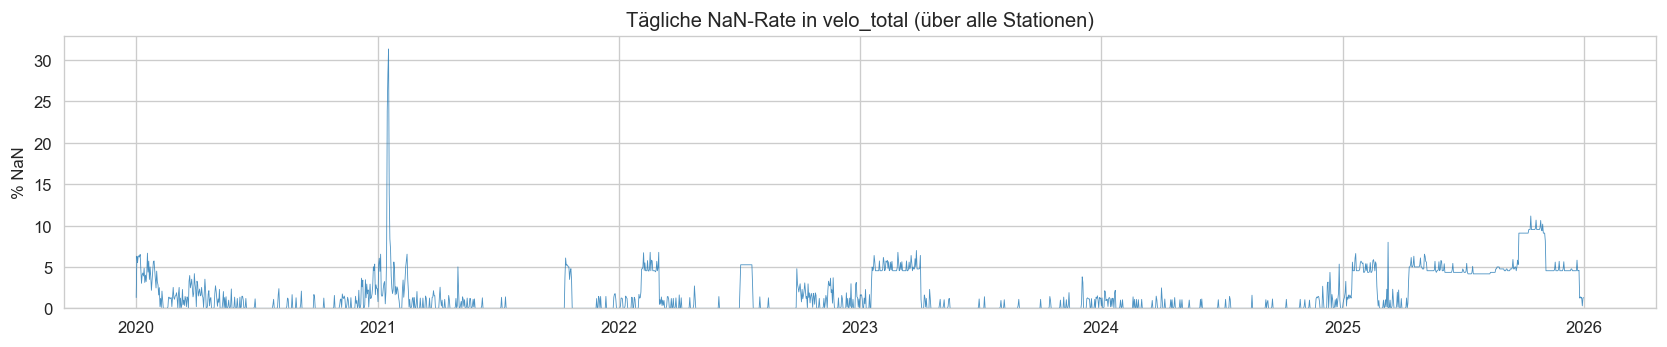

In [12]:
# Missing data overview after cleaning
print("=== Velo data after cleaning ===")
print(f"Total rows: {len(df):,}")
print(f"Stations: {df['station_id'].nunique()}")
print(f"  Consistent (for FF2): {df['is_consistent'].sum() / len(df) * 100:.1f}% of rows")
print(f"\nNull counts:")
print(df[["velo_in", "velo_out", "velo_total"]].isnull().sum())
print(f"\nvelo_total null rate: {df['velo_total'].isnull().mean()*100:.1f}%")

# Visualize missing data over time (aggregated across all stations)
daily_null_rate = (
    df.groupby(df["datetime"].dt.date)["velo_total"]
    .apply(lambda x: x.isnull().mean() * 100)
)

fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(daily_null_rate.index, daily_null_rate.values, linewidth=0.5, alpha=0.8)
ax.set_ylabel("% NaN")
ax.set_title("Tägliche NaN-Rate in velo_total (über alle Stationen)")
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

In [13]:
# Full cleaning log
log_df = pd.DataFrame(cleaning_log)
print("=== CLEANING LOG ===\n")
for _, row in log_df.iterrows():
    print(f"[{row['step']}] {row['description']}")
    print(f"     Rows affected: {row['rows_affected']:,}")
    if row['detail']:
        print(f"     Detail: {row['detail']}")
    print()

=== CLEANING LOG ===

[1.1] Loaded and concatenated yearly CSVs, renamed columns
     Rows affected: 6,347,411

[1.2] Filtered to velo-only stations, dropped fuss columns
     Rows affected: 1,847,736
     Detail: Kept 46 stations

[1.3] Removed duplicate station+datetime rows
     Rows affected: 512

[1.4] Computed velo_total (uni/bi-directional aware)
     Rows affected: 0
     Detail: 7 uni-directional, 39 bi-directional

[1.5] Flagged long zero-runs as sensor failure → NaN
     Rows affected: 68,615
     Detail: 27 stations affected, threshold=24 intervals (6h)

[1.6] Validated ranges, set negative values to NaN
     Rows affected: 0

[1.7] Identified stations with consistent multi-year coverage
     Rows affected: 0
     Detail: 6 full-span (2020-24), 12 recent (2022-24)



In [14]:
# Final assertions  -  these should all pass if the cleaning was correct
print("Running final assertions...\n")

# Velo 15-min
assert df["velo_total"].dropna().min() >= 0, "Negative velo_total values remain!"
assert pd.api.types.is_datetime64_any_dtype(df["datetime"]), "datetime not parsed!"
assert not df.duplicated(subset=["station_id", "datetime"]).any(), "Duplicates remain!"
print("[OK] Velo 15-min: no negatives, datetime parsed, no duplicates")

# Station consistency
assert len(consistent_stations) > 5, f"Only {len(consistent_stations)} consistent stations  -  check coverage threshold"
print(f"[OK] {len(consistent_stations)} consistent stations available for FF2 (2022-2024 window)")
print(f"     {len(consistent_stations_full)} stations available for full 2020-2024 span")

print("\nAll assertions passed.")

Running final assertions...

[OK] Velo 15-min: no negatives, datetime parsed, no duplicates
[OK] 12 consistent stations available for FF2 (2022-2024 window)
     6 stations available for full 2020-2024 span

All assertions passed.


In [15]:
# Stationsmetadaten und Namens-Mapping für die folgenden Schritte bereitstellen
meta = station_meta

if "station_name" in meta.columns:
    station_name_map = dict(zip(meta["station_id"], meta["station_name"]))
    n_named = meta["station_name"].notna().sum()
    print(f"Standortnamen verfuegbar fuer {n_named}/{len(meta)} Stationen.")
else:
    station_name_map = {}
    print("Warnung: Spalte 'station_name' fehlt  -  standorte_velo_fuss.json pruefen.")

def station_label(sid):
    """Liefert 'Bezeichnung (#ID)' falls verfuegbar, sonst nur '#ID'."""
    name = station_name_map.get(int(sid))
    if isinstance(name, str) and name:
        return f"{name} (#{int(sid)})"
    return f"#{int(sid)}"

print(f"\nBereinigte Velo-Daten: {len(df):,} Zeilen, {df['station_id'].nunique()} Stationen")
print(f"Zeitraum: {df['datetime'].min()} bis {df['datetime'].max()}")

Standortnamen verfuegbar fuer 46/46 Stationen.

Bereinigte Velo-Daten: 4,499,163 Zeilen, 46 Stationen
Zeitraum: 2020-01-01 00:00:00 bis 2025-12-31 23:45:00


---
## Schritt 2: Auf konsistente Stationen filtern

**Warum dieser Schritt kritisch ist:**
Für eine faire Wachstumsanalyse brauchen wir Stationen, die über den gesamten Zeitraum 2020-2025 zuverlässig Daten liefern. Würden wir Stationen einschliessen, die erst 2023 installiert wurden, würden diese fälschlich als "extremes Wachstum" erscheinen (0 → hoch). Umgekehrt: Stationen, die 2022 abgeschaltet wurden, würden als "starker Rückgang" interpretiert.

Das `is_consistent`-Flag aus Notebook 02 markiert Stationen mit ≥60% Datenabdeckung in **jedem** Jahr. Nur diese verwenden wir.

In [16]:
n_total = df["station_id"].nunique()
df_cons = df[df["is_consistent"] == True].copy()
n_consistent = df_cons["station_id"].nunique()

print(f"Total Stationen:       {n_total}")
print(f"Konsistente Stationen: {n_consistent}")
print(f"Ausgeschlossen:        {n_total - n_consistent} ({(n_total - n_consistent) / n_total * 100:.1f}%)")
print(f"Verbleibende Zeilen:   {len(df_cons):,} ({len(df_cons) / len(df) * 100:.1f}% der Daten)")

# Zeige die konsistenten Stationen
consistent_ids = sorted(df_cons["station_id"].unique())
print(f"\nKonsistente Station-IDs: {consistent_ids}")

Total Stationen:       46
Konsistente Stationen: 12
Ausgeschlossen:        34 (73.9%)
Verbleibende Zeilen:   2,190,029 (48.7% der Daten)

Konsistente Station-IDs: [np.int64(732), np.int64(1037), np.int64(2986), np.int64(2989), np.int64(2991), np.int64(2993), np.int64(2997), np.int64(3003), np.int64(3012), np.int64(4241), np.int64(4242), np.int64(4249)]


---
## Schritt 3: Sensor-Ausfälle ausschliessen

In Notebook 02 wurden zusammenhängende Null-Serien > 6 Stunden als `is_sensor_failure = True` markiert. Diese Zeilen enthalten keine echten Zähldaten  -  sie würden die Jahressummen nach unten verzerren und künstliche "Einbrüche" erzeugen.

Wir entfernen diese Zeilen **vor** der Aggregation zu Jahrestotalen.

In [17]:
# Sensor-Ausfälle entfernen (falls Spalte vorhanden)
if "is_sensor_failure" in df_cons.columns:
    n_before = len(df_cons)
    n_failures = df_cons["is_sensor_failure"].sum()
    df_cons = df_cons[df_cons["is_sensor_failure"] == False].copy()
    print(f"Sensor-Ausfälle entfernt: {n_failures:,} Zeilen ({n_failures / n_before * 100:.2f}%)")
    print(f"Verbleibend: {len(df_cons):,} Zeilen")
else:
    print("Spalte 'is_sensor_failure' nicht vorhanden  -  vermutlich bereits in NB02 gefiltert.")
    print("Prüfe NaN-Werte in velo_total als Alternative:")
    n_null = df_cons["velo_total"].isnull().sum()
    print(f"  NaN in velo_total: {n_null:,} ({n_null / len(df_cons) * 100:.2f}%)")
    # NaN-Zeilen entfernen  -  diese können nicht zu Jahressummen beitragen
    df_cons = df_cons.dropna(subset=["velo_total"]).copy()
    print(f"  Nach NaN-Entfernung: {len(df_cons):,} Zeilen")

Spalte 'is_sensor_failure' nicht vorhanden  -  vermutlich bereits in NB02 gefiltert.
Prüfe NaN-Werte in velo_total als Alternative:
  NaN in velo_total: 1,690 (0.08%)
  Nach NaN-Entfernung: 2,188,339 Zeilen


---
## Schritt 4: Datenabdeckung pro Station und Jahr prüfen

Bevor wir Jahrestotale berechnen, müssen wir wissen, wie vollständig die Daten pro Station-Jahr-Kombination sind. Ein Jahr mit nur 3 Monaten Daten darf nicht direkt mit einem Volljahr verglichen werden.

**Erwartete Intervalle pro Jahr:** 365.25 × 24 × 4 ≈ 35'064 (15-Min-Intervalle)

Wir berechnen für jede Station-Jahr-Kombination:
- Anzahl tatsächlicher Messungen
- Abdeckungsrate (coverage)
- Erster und letzter Messpunkt

In [18]:
INTERVALS_PER_YEAR = 365.25 * 24 * 4  # ~35'064

coverage = df_cons.groupby(["station_id", "year"]).agg(
    n_records=("velo_total", "count"),
    first_date=("datetime", "min"),
    last_date=("datetime", "max"),
).reset_index()

coverage["coverage_pct"] = (coverage["n_records"] / INTERVALS_PER_YEAR * 100).round(1)

# Pivot: Stationen als Zeilen, Jahre als Spalten
coverage_pivot = coverage.pivot(index="station_id", columns="year", values="coverage_pct")
print("Datenabdeckung (%) pro Station und Jahr:\n")
print(coverage_pivot.to_string())

# Zusammenfassung
print(f"\nDurchschnittliche Abdeckung pro Jahr:")
print(coverage.groupby("year")["coverage_pct"].agg(["mean", "min", "max"]).round(1))

Datenabdeckung (%) pro Station und Jahr:

year        2020  2021  2022  2023   2024  2025
station_id                                     
732         99.9  99.9  99.9  99.9  100.2  99.6
1037        99.6  99.9  99.9  99.9  100.2  99.6
2986        99.7  98.7  99.8  99.8   89.9  40.2
2989        99.6  99.9  99.9  99.9  100.2  99.6
2991        99.3  62.3  99.9  99.9  100.2  63.5
2993        93.9  87.6  98.3  98.3  100.2  86.7
2997        59.9  99.7  99.9  99.8  100.2  99.6
3003        45.7  99.6  99.9  99.9  100.2  92.3
3012         NaN  84.3  99.9  99.9  100.2  99.6
4241         NaN  31.2  99.9  99.9  100.2  99.6
4242         NaN  31.2  99.9  99.9  100.2  99.1
4249         NaN   NaN  82.9  99.9  100.2  99.6

Durchschnittliche Abdeckung pro Jahr:
      mean   min    max
year                   
2020  87.2  45.7   99.9
2021  81.3  31.2   99.9
2022  98.3  82.9   99.9
2023  99.8  98.3   99.9
2024  99.3  89.9  100.2
2025  89.9  40.2   99.6


---
## Schritt 5: Partielle Jahre behandeln (insb. 2025)

**Problem:** 2025 ist wahrscheinlich noch nicht vollständig (die Daten enden irgendwann Mitte des Jahres). Ein Jahrestotal von z.B. 500'000 für Jan-März 2025 wäre nicht vergleichbar mit 2'000'000 für das Gesamtjahr 2024.

**Strategie:** Wir verwenden zwei Ansätze:
1. **Annualisierung**  -  Hochrechnung auf 12 Monate basierend auf der tatsächlichen Abdeckung: `annualized = raw_total / coverage × 100`
2. **Ausschluss**  -  Jahre mit <50% Abdeckung komplett ausschliessen (konservativer Ansatz)

Wir berechnen beide und verwenden primär die Annualisierung  -  mit einem Mindest-Coverage-Schwellenwert von 25%, unter dem die Hochrechnung zu unsicher wird.

In [19]:
MIN_COVERAGE_PCT = 25  # Unter 25% Abdeckung wird nicht annualisiert

# Jahrestotale berechnen (Rohsumme)
yearly_raw = df_cons.groupby(["station_id", "year"]).agg(
    velo_total_sum=("velo_total", "sum"),
    n_records=("velo_total", "count"),
).reset_index()

# Coverage hinzufügen
yearly_raw["coverage_pct"] = (yearly_raw["n_records"] / INTERVALS_PER_YEAR * 100)

# Annualisierte Totale berechnen
# Formel: annualized = raw_sum / (coverage_pct / 100)
# Beispiel: 500k bei 25% coverage → 500k / 0.25 = 2M geschätztes Jahrestotal
yearly_raw["velo_annual"] = np.where(
    yearly_raw["coverage_pct"] >= MIN_COVERAGE_PCT,
    yearly_raw["velo_total_sum"] / (yearly_raw["coverage_pct"] / 100),
    np.nan  # Zu wenig Daten → nicht verwenden
)

# Wie viele Station-Jahre werden ausgeschlossen?
n_excluded = yearly_raw["velo_annual"].isnull().sum()
n_total_sy = len(yearly_raw)
print(f"Station-Jahre mit <{MIN_COVERAGE_PCT}% Abdeckung (ausgeschlossen): {n_excluded}/{n_total_sy}")

# Zeige 2025 separat
y2025 = yearly_raw[yearly_raw["year"] == 2025]
if len(y2025) > 0:
    print(f"\n2025 Details:")
    print(f"  Abdeckung: {y2025['coverage_pct'].mean():.1f}% (Durchschnitt)")
    print(f"  Annualisiert: {'Ja' if y2025['velo_annual'].notnull().any() else 'Nein (zu wenig Daten)'}")
else:
    print("\nKeine Daten für 2025 vorhanden.")

# Zeige Pivot der annualisierten Werte
annual_pivot = yearly_raw.pivot(index="station_id", columns="year", values="velo_annual")
print(f"\nAnnualisierte Jahrestotale pro Station (gerundet):")
print(annual_pivot.round(0).to_string())

Station-Jahre mit <25% Abdeckung (ausgeschlossen): 0/67

2025 Details:
  Abdeckung: 89.9% (Durchschnitt)
  Annualisiert: Ja

Annualisierte Jahrestotale pro Station (gerundet):
year             2020       2021       2022       2023       2024       2025
station_id                                                                  
732          368600.0   372428.0   427545.0   428687.0   439347.0   452989.0
1037         941219.0   931368.0  1017098.0   988442.0   945187.0   951444.0
2986         322611.0   264503.0   282372.0   274164.0   283663.0   324438.0
2989        1830274.0  1359449.0  1371181.0  1341493.0  1307374.0  1289192.0
2991         222373.0   226786.0   600950.0   558147.0   477828.0   369780.0
2993         551930.0   514828.0   604371.0   568950.0   565005.0   549772.0
2997         457319.0   382746.0   407434.0   393364.0   372850.0   421333.0
3003         216834.0   201762.0   230963.0   318302.0   365405.0   405792.0
3012              NaN   514151.0   537327.0   525180.0

---
## Schritt 6: Saisonalitäts-Check der Annualisierung

**Wichtige Einschränkung:** Die einfache Annualisierung (Rohsumme / Abdeckung) nimmt implizit an, dass Veloverkehr gleichmässig über das Jahr verteilt ist. Das stimmt **nicht**  -  Veloverkehr ist stark saisonabhängig (Sommer >> Winter).

Wenn 2025 z.B. nur Januar-März abdeckt (Wintermonate mit wenig Verkehr), wird die Hochrechnung das Gesamtjahr **unterschätzen**. Umgekehrt bei Sommerdaten.

**Lösung:** Wir prüfen die saisonale Verteilung und visualisieren die monatlichen Durchschnitte. Falls 2025 stark verzerrt ist, verwenden wir nur vollständige Jahre (2020-2024) für die Regression.

2025 deckt Monate [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12] ab


Diese Monate machen 100.0% des typischen Jahresverkehrs aus
Einfache Annualisierung würde um Faktor 1.00 statt 1.00 hochrechnen
Saisonale Verzerrung akzeptabel  -  2025 kann verwendet werden.


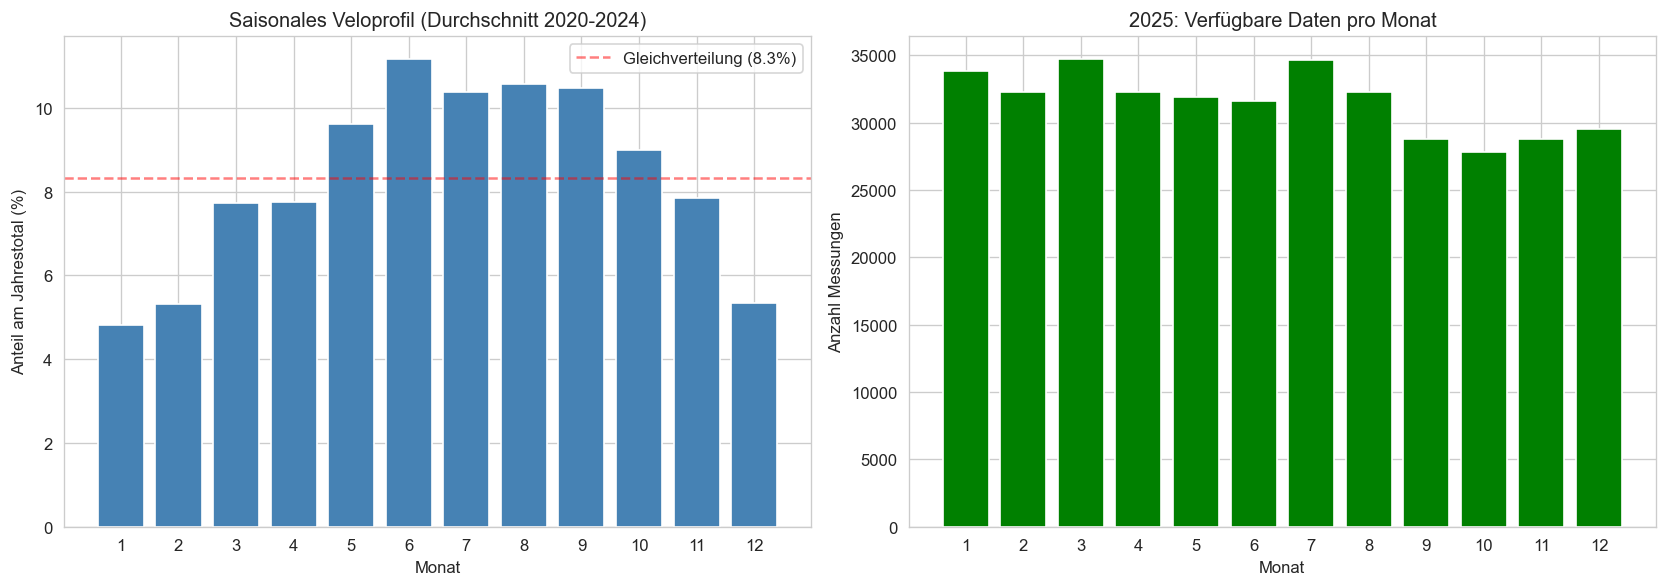

In [20]:
# Monatliche Totale über alle konsistenten Stationen  -  saisonales Profil
monthly = df_cons.groupby(["year", "month"])["velo_total"].sum().reset_index()

# Saisonprofil: Durchschnitt pro Monat über die vollständigen Jahre
full_years = [y for y in sorted(df_cons["year"].unique()) if y <= 2024]
monthly_profile = (
    monthly[monthly["year"].isin(full_years)]
    .groupby("month")["velo_total"]
    .mean()
)

# Normalisieren: jeder Monat als Anteil am Jahrestotal
monthly_share = monthly_profile / monthly_profile.sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Links: Saisonprofil
axes[0].bar(monthly_share.index, monthly_share.values * 100, color="steelblue")
axes[0].set_xlabel("Monat")
axes[0].set_ylabel("Anteil am Jahrestotal (%)")
axes[0].set_title(f"Saisonales Veloprofil (Durchschnitt {full_years[0]}-{full_years[-1]})")
axes[0].set_xticks(range(1, 13))
axes[0].axhline(y=100/12, color="red", linestyle="--", alpha=0.5, label="Gleichverteilung (8.3%)")
axes[0].legend()

# Rechts: 2025 Abdeckung  -  welche Monate haben wir?
if 2025 in df_cons["year"].unique():
    m2025 = df_cons[df_cons["year"] == 2025].groupby("month")["velo_total"].count()
    coverage_2025 = pd.Series(0, index=range(1, 13))
    coverage_2025.update(m2025)
    colors = ["green" if v > 0 else "lightgray" for v in coverage_2025.values]
    axes[1].bar(coverage_2025.index, coverage_2025.values, color=colors)
    axes[1].set_xlabel("Monat")
    axes[1].set_ylabel("Anzahl Messungen")
    axes[1].set_title("2025: Verfügbare Daten pro Monat")
    axes[1].set_xticks(range(1, 13))
    
    # Berechne saisonale Verzerrung: Anteil der vorhandenen Monate am Jahresprofil
    covered_months = [m for m in range(1, 13) if coverage_2025[m] > 0]
    seasonal_share = monthly_share[covered_months].sum()
    print(f"2025 deckt Monate {covered_months} ab")
    print(f"Diese Monate machen {seasonal_share * 100:.1f}% des typischen Jahresverkehrs aus")
    print(f"Einfache Annualisierung würde um Faktor {1/seasonal_share:.2f} statt {12/len(covered_months):.2f} hochrechnen")
    
    if abs(seasonal_share - len(covered_months) / 12) > 0.05:
        print("⚠ Saisonale Verzerrung erkannt  -  2025 wird für Regression ausgeschlossen!")
        EXCLUDE_2025 = True
    else:
        print("Saisonale Verzerrung akzeptabel  -  2025 kann verwendet werden.")
        EXCLUDE_2025 = False
else:
    axes[1].text(0.5, 0.5, "Keine 2025-Daten", ha="center", va="center", transform=axes[1].transAxes)
    EXCLUDE_2025 = True
    print("Keine 2025-Daten vorhanden  -  Regression nur mit 2020-2024.")

plt.tight_layout()
plt.show()

---
## Schritt 7: Finale Jahrestotale für die Regression

Basierend auf dem Saisonalitäts-Check erstellen wir nun die endgültigen Jahrestotale pro Station, die in die Trendanalyse eingehen. Wir verwenden die annualisierten Werte für vollständige Jahre und schliessen stark verzerrte partielle Jahre aus.

In [21]:
# Finale Jahrestotale: nur verwendbare Jahre
if EXCLUDE_2025:
    yearly = yearly_raw[yearly_raw["year"] <= 2024].copy()
    print("2025 ausgeschlossen wegen saisonaler Verzerrung oder fehlender Daten.")
else:
    yearly = yearly_raw.copy()

# Nur Zeilen mit gültigen annualisierten Werten
yearly = yearly.dropna(subset=["velo_annual"])

# Verwendete Jahre
years_used = sorted(yearly["year"].unique())
print(f"Verwendete Jahre: {years_used}")
print(f"Stationen: {yearly['station_id'].nunique()}")
print(f"Station-Jahr-Kombinationen: {len(yearly)}")

# Pivot für Übersicht
final_pivot = yearly.pivot(index="station_id", columns="year", values="velo_annual")
print(f"\nFinale annualisierte Jahrestotale:")
print(final_pivot.round(0).to_string())

Verwendete Jahre: [np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]
Stationen: 12
Station-Jahr-Kombinationen: 67

Finale annualisierte Jahrestotale:
year             2020       2021       2022       2023       2024       2025
station_id                                                                  
732          368600.0   372428.0   427545.0   428687.0   439347.0   452989.0
1037         941219.0   931368.0  1017098.0   988442.0   945187.0   951444.0
2986         322611.0   264503.0   282372.0   274164.0   283663.0   324438.0
2989        1830274.0  1359449.0  1371181.0  1341493.0  1307374.0  1289192.0
2991         222373.0   226786.0   600950.0   558147.0   477828.0   369780.0
2993         551930.0   514828.0   604371.0   568950.0   565005.0   549772.0
2997         457319.0   382746.0   407434.0   393364.0   372850.0   421333.0
3003         216834.0   201762.0   230963.0   318302.0   365405.0   405792.0
3012              NaN   514151.0  

---
## Schritt 8: Year-over-Year (YoY) Wachstumsraten

Bevor wir die Regression durchführen, berechnen wir die jährlichen Wachstumsraten pro Station. Das gibt uns ein erstes Bild, welche Stationen wachsen und welche schrumpfen.

**Formel:** `YoY = (Total_t - Total_{t-1}) / Total_{t-1} × 100`

Positive Werte = Wachstum, negative = Rückgang.

In [22]:
# YoY Wachstumsraten pro Station
yearly_sorted = yearly.sort_values(["station_id", "year"])
yearly_sorted["yoy_pct"] = (
    yearly_sorted.groupby("station_id")["velo_annual"]
    .pct_change() * 100
)

# Pivot der YoY-Raten
yoy_pivot = yearly_sorted.pivot(index="station_id", columns="year", values="yoy_pct")
print("Year-over-Year Wachstumsraten (%):\n")
print(yoy_pivot.round(1).to_string())

# Durchschnittliche YoY-Rate pro Station
avg_yoy = yearly_sorted.groupby("station_id")["yoy_pct"].mean().sort_values(ascending=False)
print(f"\nDurchschnittliche jährliche Wachstumsrate pro Station:")
for sid, rate in avg_yoy.items():
    arrow = "▲" if rate > 0 else "▼"
    print(f"  {station_label(sid):<48s} {arrow} {rate:+.1f}%/Jahr")

Year-over-Year Wachstumsraten (%):

year        2020  2021   2022  2023  2024  2025
station_id                                     
732          NaN   1.0   14.8   0.3   2.5   3.1
1037         NaN  -1.0    9.2  -2.8  -4.4   0.7
2986         NaN -18.0    6.8  -2.9   3.5  14.4
2989         NaN -25.7    0.9  -2.2  -2.5  -1.4
2991         NaN   2.0  165.0  -7.1 -14.4 -22.6
2993         NaN  -6.7   17.4  -5.9  -0.7  -2.7
2997         NaN -16.3    6.5  -3.5  -5.2  13.0
3003         NaN  -7.0   14.5  37.8  14.8  11.1
3012         NaN   NaN    4.5  -2.3  -1.8   3.4
4241         NaN   NaN    9.0  -9.8   3.5  -6.8
4242         NaN   NaN   12.9   1.0   8.0  -0.9
4249         NaN   NaN    NaN  -7.8   2.9  -8.7

Durchschnittliche jährliche Wachstumsrate pro Station:
  Talstrasse (#2991)                               ▲ +24.6%/Jahr
  Baslerstrasse (#3003)                            ▲ +14.2%/Jahr
  Langstrasse (Fahrbahn Nord) (#4242)              ▲ +5.3%/Jahr
  Hardbrücke Nord (Seite Altstetten) (#732

---
## Schritt 9: Lineare Regression pro Station

Die Kernanalyse von FF2: Für jede Station fitten wir eine lineare Regression `velo_annual ~ year`. Die Steigung (slope) zeigt den absoluten Wachstumstrend in Velofahrten/Jahr.

**Warum lineare Regression?**
- Einfach interpretierbar: "Station X gewinnt Y Fahrten pro Jahr dazu"
- Robust gegenüber einzelnen Ausreisser-Jahren
- Direkt extrapolierbar
- R²-Wert zeigt, wie linear (= konsistent) der Trend ist

Wir berechnen pro Station:
- **Slope**: Absolute Veränderung pro Jahr
- **R²**: Güte des linearen Fits (0-1, höher = konsistenterer Trend)
- **p-value**: Statistische Signifikanz des Trends

In [23]:
def fit_station_trend(group):
    """Lineare Regression für eine Station über die Jahre."""
    x = group["year"].values
    y = group["velo_annual"].values
    
    # Mindestens 3 Datenpunkte für sinnvolle Regression
    if len(x) < 3:
        return pd.Series({
            "slope": np.nan, "intercept": np.nan,
            "r_squared": np.nan, "p_value": np.nan,
            "n_years": len(x), "first_year_total": y[0],
            "last_year_total": y[-1],
        })
    
    result = stats.linregress(x, y)
    return pd.Series({
        "slope": result.slope,
        "intercept": result.intercept,
        "r_squared": result.rvalue ** 2,
        "p_value": result.pvalue,
        "n_years": len(x),
        "first_year_total": y[0],
        "last_year_total": y[-1],
    })

# Regression pro Station
trends = yearly.sort_values("year").groupby("station_id").apply(fit_station_trend).reset_index()

# Relative Steigung: slope als % des Durchschnittsaufkommens
station_means = yearly.groupby("station_id")["velo_annual"].mean()
trends["mean_annual"] = trends["station_id"].map(station_means)
trends["slope_pct"] = (trends["slope"] / trends["mean_annual"] * 100)

# Sortieren nach stärkstem relativem Wachstum
trends = trends.sort_values("slope_pct", ascending=False)


# Standortnamen anhaengen (fuer alle nachfolgenden Ausgaben)
trends["station_name"] = trends["station_id"].map(station_name_map).fillna("")
print("Regressionsergebnisse pro Station (sortiert nach relativem Wachstum):\n")
display_cols = ["station_id", "station_name", "slope", "slope_pct", "r_squared", "p_value", "n_years", "mean_annual"]
print(trends[display_cols].to_string(
    index=False,
    formatters={
        "slope": "{:+,.0f}".format,
        "slope_pct": "{:+.1f}%".format,
        "r_squared": "{:.3f}".format,
        "p_value": "{:.4f}".format,
        "mean_annual": "{:,.0f}".format,
    }
))

Regressionsergebnisse pro Station (sortiert nach relativem Wachstum):

 station_id                       station_name   slope slope_pct r_squared p_value  n_years mean_annual
       3003                      Baslerstrasse +43,516    +15.0%     0.907  0.0033      6.0     289,843
       2991                         Talstrasse +41,353    +10.1%     0.224  0.3427      6.0     409,311
       4242        Langstrasse (Fahrbahn Nord) +17,570     +4.8%     0.857  0.0241      5.0     369,744
        732 Hardbrücke Nord (Seite Altstetten) +17,824     +4.3%     0.876  0.0060      6.0     414,933
       2986                     Andreasstrasse  +1,669     +0.6%     0.015  0.8166      6.0     291,958
       2993                  Scheuchzerstrasse  +2,981     +0.5%     0.036  0.7176      6.0     559,143
       3012                       Bucheggplatz  +1,681     +0.3%     0.067  0.6740      5.0     525,163
       1037          Hardbrücke Süd (Seite HB)  +1,827     +0.2%     0.011  0.8460      6.0     9

---
## Schritt 10: CAGR (Compound Annual Growth Rate)

Neben der linearen Regression berechnen wir die CAGR  -  die zusammengesetzte jährliche Wachstumsrate. Diese misst das *durchschnittliche* jährliche Wachstum unter Berücksichtigung von Zinseszins-Effekten.

**Formel:** `CAGR = (Endwert / Anfangswert)^(1/n) - 1`

Die CAGR ist besonders nützlich für die Verdopplungsfrage: Bei konstantem Wachstum verdoppelt sich das Aufkommen in `ln(2) / ln(1 + CAGR)` Jahren.

In [24]:
# CAGR berechnen
n_periods = trends["n_years"] - 1  # Anzahl Übergänge zwischen Jahren

trends["cagr"] = np.where(
    (trends["first_year_total"] > 0) & (n_periods > 0),
    (trends["last_year_total"] / trends["first_year_total"]) ** (1 / n_periods) - 1,
    np.nan
)

# Verdopplungszeit: Jahre bis sich das Aufkommen verdoppelt
# Nur für positive CAGR sinnvoll
trends["doubling_years"] = np.where(
    trends["cagr"] > 0,
    np.log(2) / np.log(1 + trends["cagr"]),
    np.inf  # Kein Wachstum → verdoppelt sich nie
)

# Wird sich die Station innerhalb von 5 Jahren verdoppeln?
trends["doubles_in_5y"] = trends["doubling_years"] <= 5

print("CAGR und Verdopplungszeit:\n")
cagr_display = trends[["station_id", "cagr", "doubling_years", "doubles_in_5y", "first_year_total", "last_year_total"]].copy()
cagr_display = cagr_display.sort_values("cagr", ascending=False)

for _, row in cagr_display.iterrows():
    cagr_str = f"{row['cagr']*100:+.1f}%/Jahr" if pd.notnull(row['cagr']) else "N/A"
    doubl_str = f"{row['doubling_years']:.1f} Jahre" if row['doubling_years'] < 100 else "nie"
    flag = " ★ VERDOPPLUNG <5J" if row['doubles_in_5y'] else ""
    print(f"  {station_label(row['station_id']):<48s} CAGR {cagr_str:>12}  Verdopplung in {doubl_str:>12}{flag}")

n_doubling = trends["doubles_in_5y"].sum()
print(f"\n→ {n_doubling} Station(en) verdoppeln ihr Aufkommen voraussichtlich innerhalb von 5 Jahren.")

# Trend-Qualität (für spätere Hover-Tooltips und Filter)
def _classify_trend(row):
    if pd.isnull(row["p_value"]):
        return "insufficient_data"
    if row["p_value"] < 0.05 and row["r_squared"] >= 0.7:
        return "strong"
    if row["p_value"] < 0.10 or row["r_squared"] >= 0.5:
        return "moderate"
    return "weak"

trends["trend_quality"] = trends.apply(_classify_trend, axis=1)


CAGR und Verdopplungszeit:

  Baslerstrasse (#3003)                            CAGR  +13.4%/Jahr  Verdopplung in    5.5 Jahre
  Talstrasse (#2991)                               CAGR  +10.7%/Jahr  Verdopplung in    6.8 Jahre
  Langstrasse (Fahrbahn Nord) (#4242)              CAGR   +5.1%/Jahr  Verdopplung in   13.9 Jahre
  Hardbrücke Nord (Seite Altstetten) (#732)        CAGR   +4.2%/Jahr  Verdopplung in   16.8 Jahre
  Bucheggplatz (#3012)                             CAGR   +0.9%/Jahr  Verdopplung in   75.9 Jahre
  Hardbrücke Süd (Seite HB) (#1037)                CAGR   +0.2%/Jahr  Verdopplung in          nie
  Andreasstrasse (#2986)                           CAGR   +0.1%/Jahr  Verdopplung in          nie
  Scheuchzerstrasse (#2993)                        CAGR   -0.1%/Jahr  Verdopplung in          nie
  Langstrasse (Fahrbahn Süd) (#4241)               CAGR   -1.3%/Jahr  Verdopplung in          nie
  Lux-Guyer-Weg (#2997)                            CAGR   -1.6%/Jahr  Verdopplung in      

---
## Schritt 11: Trendextrapolation visualisieren

Wir visualisieren die Trendlinien für alle Stationen  -  mit 5-Jahres-Projektion. Die Extrapolation zeigt, wo bei Fortschreibung der aktuellen Trends die Kapazitätsgrenzen als erstes erreicht werden.

**Wichtig:** Extrapolation ist keine Prognose! Lineare Fortschreibung ignoriert Sättigungseffekte, politische Änderungen und externe Schocks. Sie dient als Planungsinstrument ("Was passiert, wenn nichts getan wird?"), nicht als Vorhersage.

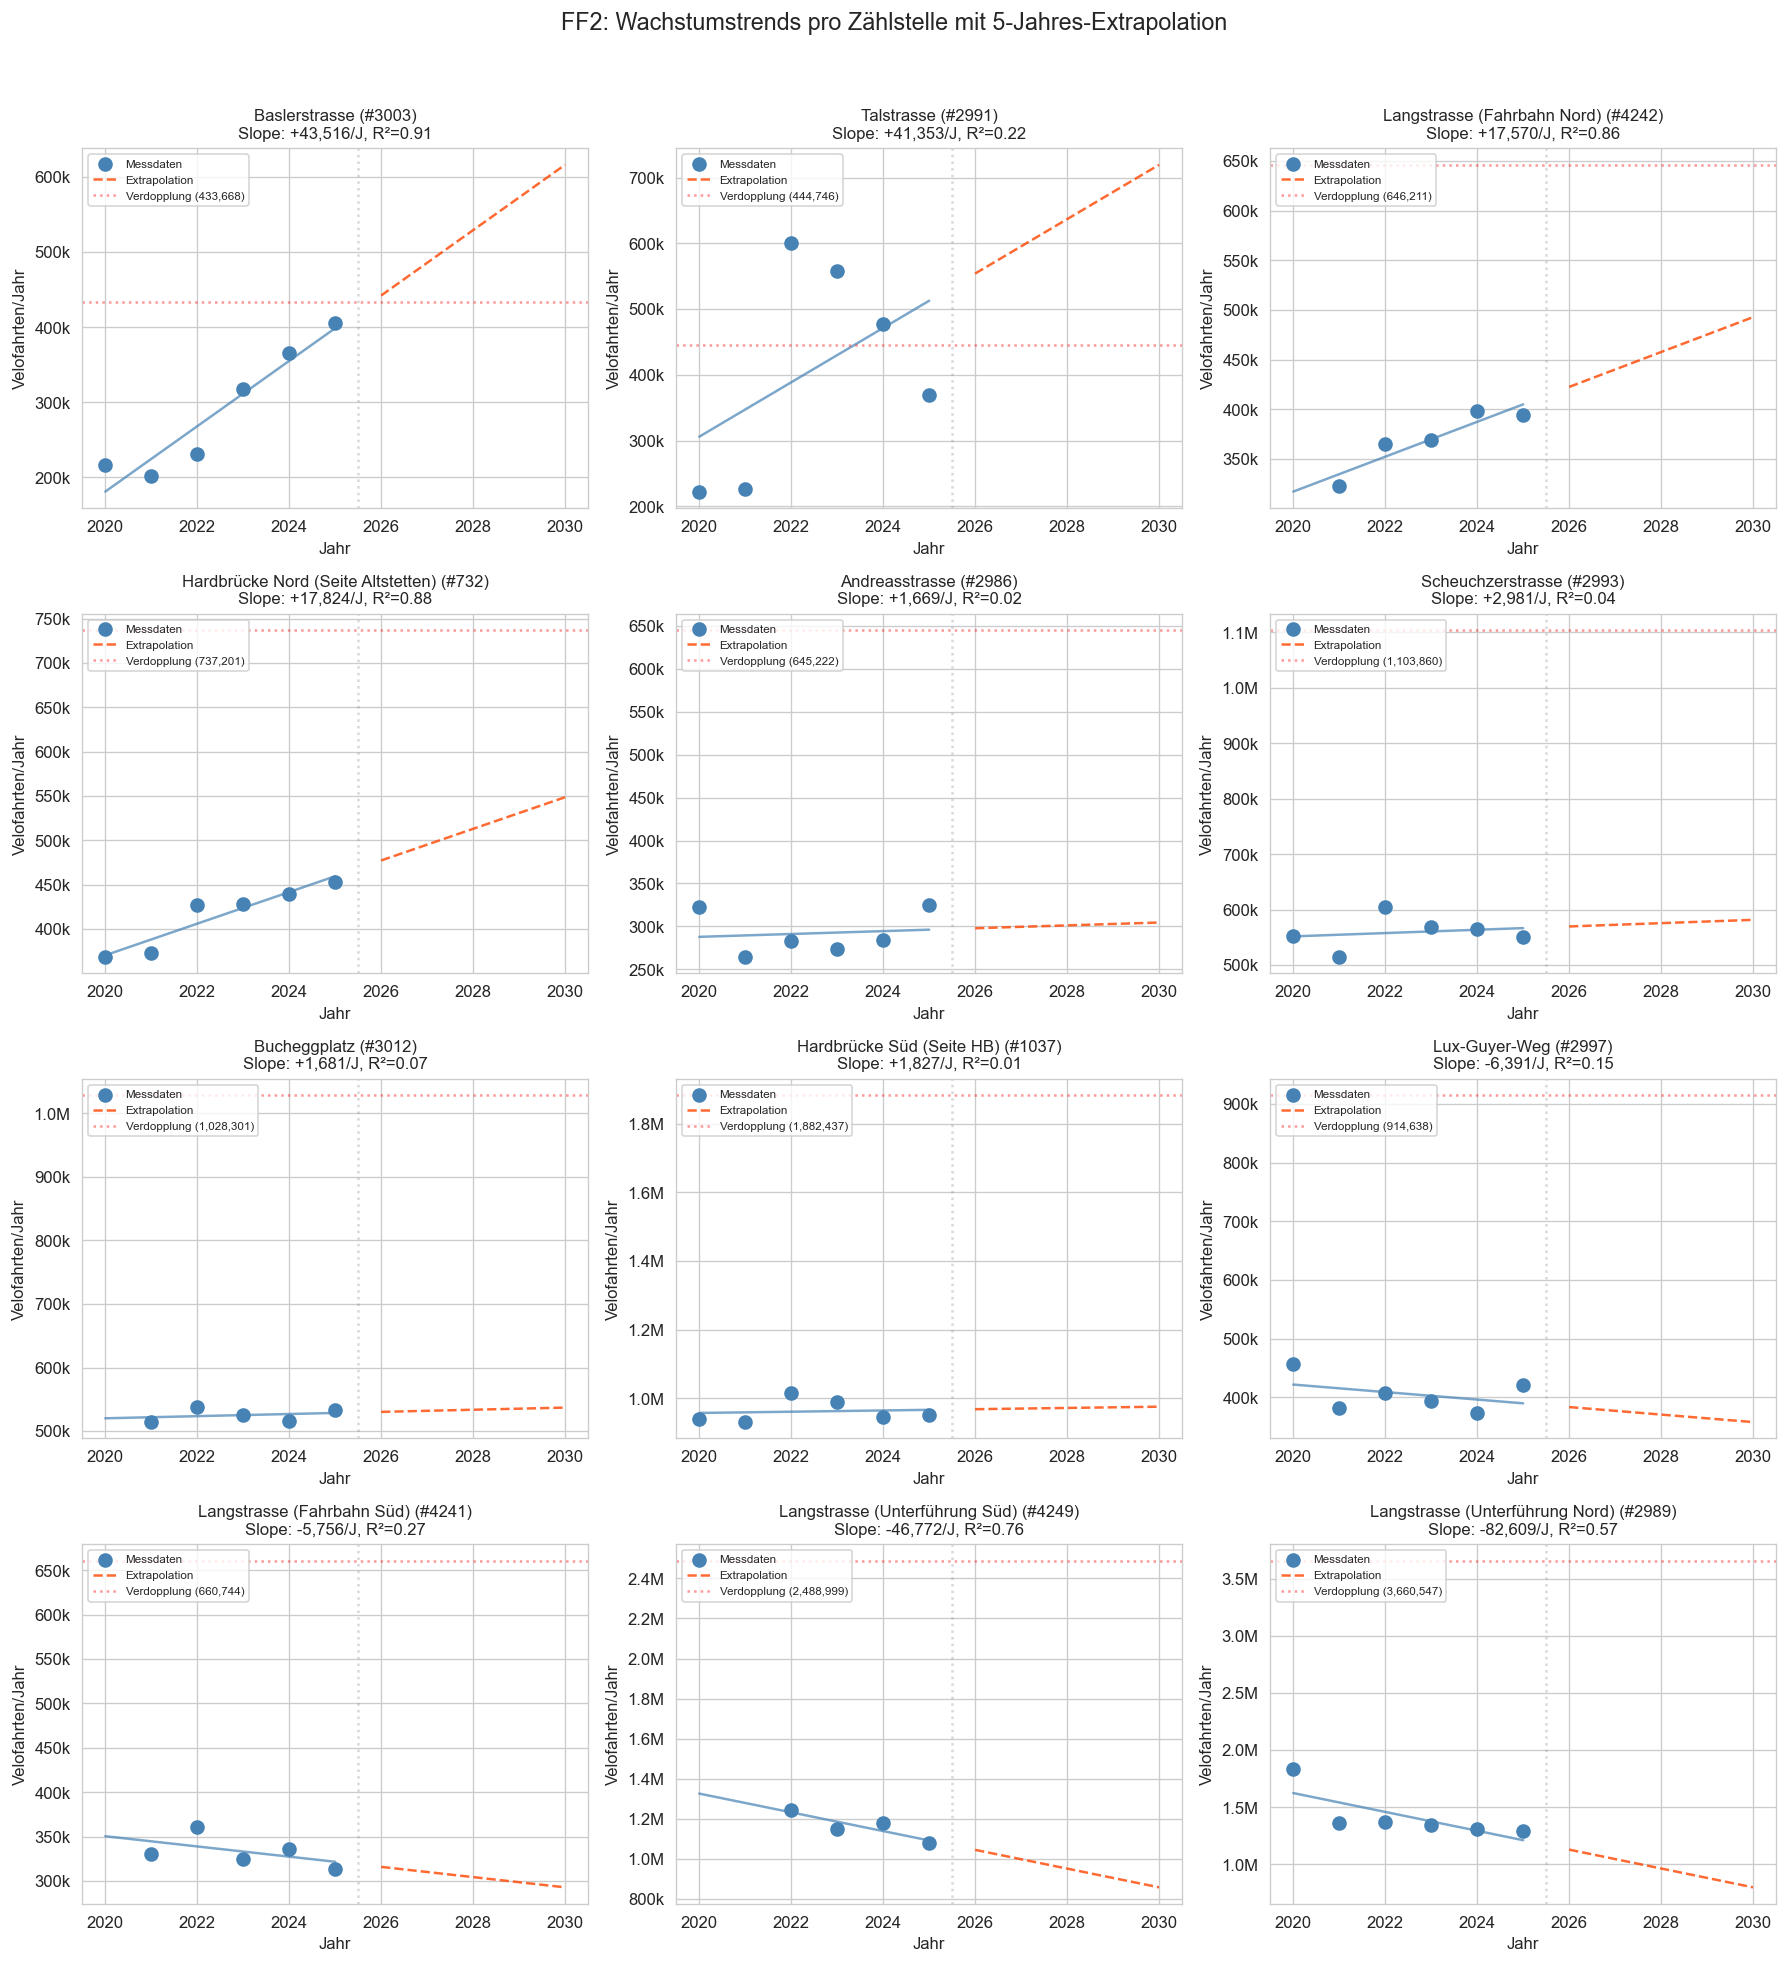

In [25]:
# Trendlinien mit Extrapolation
EXTRAPOLATION_YEARS = 5
last_data_year = max(years_used)
future_years = np.arange(last_data_year + 1, last_data_year + EXTRAPOLATION_YEARS + 1)
all_years_plot = np.arange(min(years_used), last_data_year + EXTRAPOLATION_YEARS + 1)

# Anzahl Stationen bestimmt das Grid-Layout
n_stations = len(trends)
n_cols = min(3, n_stations)
n_rows = int(np.ceil(n_stations / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)
axes_flat = axes.flatten()

for i, (_, row) in enumerate(trends.iterrows()):
    ax = axes_flat[i]
    sid = row["station_id"]
    
    # Tatsächliche Daten
    station_data = yearly[yearly["station_id"] == sid].sort_values("year")
    ax.scatter(station_data["year"], station_data["velo_annual"], 
               color="steelblue", zorder=5, s=60, label="Messdaten")
    
    if pd.notnull(row["slope"]):
        # Trendlinie (historisch)
        trend_y_hist = row["intercept"] + row["slope"] * np.array(years_used, dtype=float)
        ax.plot(years_used, trend_y_hist, color="steelblue", linestyle="-", alpha=0.7)
        
        # Extrapolation (Zukunft)
        trend_y_future = row["intercept"] + row["slope"] * future_years.astype(float)
        ax.plot(future_years, trend_y_future, color="orangered", linestyle="--", alpha=0.8, label="Extrapolation")
        
        # Verdopplungslinie
        double_val = row["first_year_total"] * 2
        ax.axhline(y=double_val, color="red", linestyle=":", alpha=0.4, label=f"Verdopplung ({double_val:,.0f})")
    
    # Trennlinie: historisch vs. Zukunft
    ax.axvline(x=last_data_year + 0.5, color="gray", linestyle=":", alpha=0.3)
    
    ax.set_title(f"{station_label(sid)}\nSlope: {row['slope']:+,.0f}/J, R²={row['r_squared']:.2f}", fontsize=10)
    ax.set_xlabel("Jahr")
    ax.set_ylabel("Velofahrten/Jahr")
    ax.legend(fontsize=7, loc="upper left")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}k"))

# Leere Subplots ausblenden
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle("FF2: Wachstumstrends pro Zählstelle mit 5-Jahres-Extrapolation", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Schritt 12: Wachstums-Ranking  -  Übersichtskarte

Ein Balkendiagramm mit dem Wachstums-Ranking aller Stationen. Wir zeigen sowohl den absoluten Trend (Slope) als auch den relativen Trend (CAGR), da beide unterschiedliche Perspektiven bieten:
- **Absoluter Trend (Slope):** Wo werden absolut die meisten zusätzlichen Fahrten generiert?
- **Relativer Trend (CAGR):** Wo wächst der Verkehr am stärksten *im Verhältnis zum bestehenden Aufkommen*?

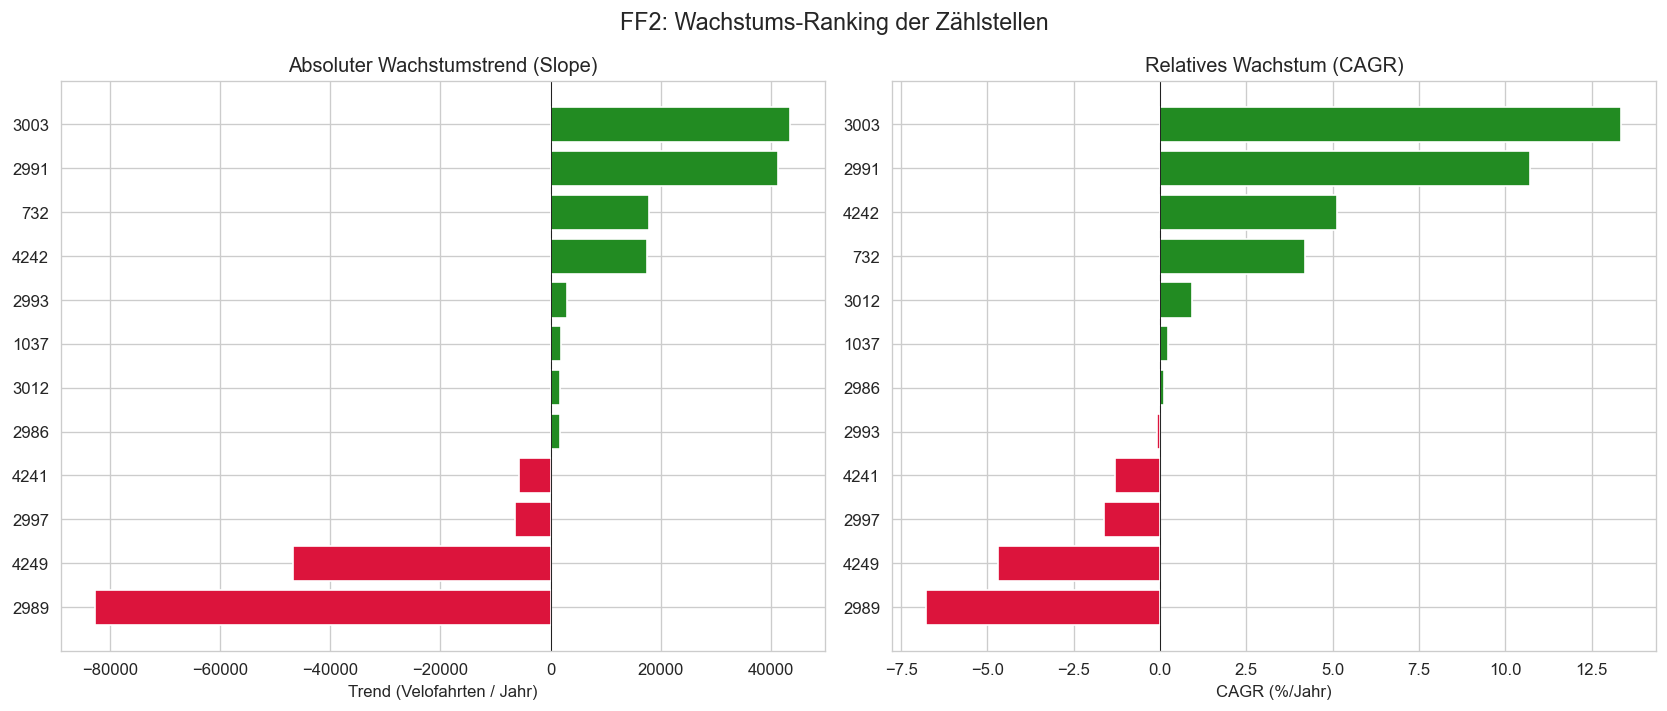

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, max(6, n_stations * 0.4)))

# Links: Absoluter Trend (Slope)
trends_abs = trends.dropna(subset=["slope"]).sort_values("slope")
colors_abs = ["forestgreen" if s > 0 else "crimson" for s in trends_abs["slope"]]
axes[0].barh(trends_abs["station_id"].astype(str), trends_abs["slope"], color=colors_abs)
axes[0].set_xlabel("Trend (Velofahrten / Jahr)")
axes[0].set_title("Absoluter Wachstumstrend (Slope)")
axes[0].axvline(x=0, color="black", linewidth=0.5)

# Rechts: Relativer Trend (CAGR)
trends_rel = trends.dropna(subset=["cagr"]).sort_values("cagr")
colors_rel = ["forestgreen" if c > 0 else "crimson" for c in trends_rel["cagr"]]
axes[1].barh(trends_rel["station_id"].astype(str), trends_rel["cagr"] * 100, color=colors_rel)
axes[1].set_xlabel("CAGR (%/Jahr)")
axes[1].set_title("Relatives Wachstum (CAGR)")
axes[1].axvline(x=0, color="black", linewidth=0.5)

fig.suptitle("FF2: Wachstums-Ranking der Zählstellen", fontsize=14)
plt.tight_layout()
plt.show()

---
## Schritt 13: Signifikanzfilter  -  Welche Trends sind statistisch belastbar?

Nicht jeder berechnete Trend ist statistisch signifikant. Ein R² von 0.1 bei 4 Datenpunkten hat wenig Aussagekraft. Wir klassifizieren die Trends:

- **Starker Trend:** p-value < 0.05 UND R² ≥ 0.7 → Konsistentes, signifikantes Wachstum
- **Moderater Trend:** p-value < 0.10 ODER R² ≥ 0.5 → Richtung erkennbar, aber nicht eindeutig
- **Schwacher/kein Trend:** Alles andere → Kein belastbarer Wachstumstrend

Für die Priorisierung (CPA Step 5) verwenden wir nur Stationen mit starkem oder moderatem Trend.

In [27]:
def classify_trend(row):
    if pd.isnull(row["p_value"]):
        return "insufficient_data"
    if row["p_value"] < 0.05 and row["r_squared"] >= 0.7:
        return "strong"
    if row["p_value"] < 0.10 or row["r_squared"] >= 0.5:
        return "moderate"
    return "weak"

trends["trend_quality"] = trends.apply(classify_trend, axis=1)

# Zusammenfassung
print("Trendqualität der Stationen:\n")
for quality in ["strong", "moderate", "weak", "insufficient_data"]:
    subset = trends[trends["trend_quality"] == quality]
    label = {
        "strong": "Stark (p<0.05, R²≥0.7)",
        "moderate": "Moderat (p<0.10 oder R²≥0.5)",
        "weak": "Schwach",
        "insufficient_data": "Zu wenig Daten",
    }[quality]
    stations = ", ".join(station_label(s) for s in subset["station_id"].values)
    print(f"  {label}: {len(subset)} Stationen")
    if len(subset) > 0:
        print(f"    → {stations}")

# Wachstums-Hotspots: starkes oder moderates Wachstum
hotspots = trends[
    (trends["trend_quality"].isin(["strong", "moderate"])) & 
    (trends["slope"] > 0)
].sort_values("slope_pct", ascending=False)

print(f"\n{'='*60}")
print(f"WACHSTUMS-HOTSPOTS (statistisch belastbar, positiver Trend):")
print(f"{'='*60}")
if len(hotspots) > 0:
    for _, row in hotspots.iterrows():
        print(f"  {station_label(row['station_id'])}: {row['slope']:+,.0f} Fahrten/Jahr "
              f"({row['slope_pct']:+.1f}%), CAGR {row['cagr']*100:+.1f}%, "
              f"R²={row['r_squared']:.2f}, Verdopplung in {row['doubling_years']:.1f}J")
else:
    print("  Keine Stationen mit statistisch signifikantem Wachstumstrend gefunden.")

Trendqualität der Stationen:

  Stark (p<0.05, R²≥0.7): 3 Stationen
    → Baslerstrasse (#3003), Langstrasse (Fahrbahn Nord) (#4242), Hardbrücke Nord (Seite Altstetten) (#732)
  Moderat (p<0.10 oder R²≥0.5): 2 Stationen
    → Langstrasse (Unterführung Süd) (#4249), Langstrasse (Unterführung Nord) (#2989)
  Schwach: 7 Stationen
    → Talstrasse (#2991), Andreasstrasse (#2986), Scheuchzerstrasse (#2993), Bucheggplatz (#3012), Hardbrücke Süd (Seite HB) (#1037), Lux-Guyer-Weg (#2997), Langstrasse (Fahrbahn Süd) (#4241)
  Zu wenig Daten: 0 Stationen

WACHSTUMS-HOTSPOTS (statistisch belastbar, positiver Trend):
  Baslerstrasse (#3003): +43,516 Fahrten/Jahr (+15.0%), CAGR +13.4%, R²=0.91, Verdopplung in 5.5J
  Langstrasse (Fahrbahn Nord) (#4242): +17,570 Fahrten/Jahr (+4.8%), CAGR +5.1%, R²=0.86, Verdopplung in 13.9J
  Hardbrücke Nord (Seite Altstetten) (#732): +17,824 Fahrten/Jahr (+4.3%), CAGR +4.2%, R²=0.88, Verdopplung in 16.8J


---
## Schritt 14: CPA-Entscheidungsgrundlage (Step 5)

Basierend auf den Ergebnissen formulieren wir die Entscheidungsgrundlage gemäss dem CPA-Framework:

**Wenn Wachstum konzentriert (Ergebnis A):**
> Präventive Kapazitätserweiterung an den identifizierten Wachstums-Hotspots einplanen. Die Dringlichkeit ergibt sich aus der Verdopplungszeit.

**Wenn Wachstum gleichmässig (Ergebnis B):**
> Netzweite Standards anheben (z.B. Mindestbreiten, Signalisation). Einzelstandort-Priorisierung ist weniger sinnvoll.

In [28]:
# Konzentrations-Analyse: Ist das Wachstum auf wenige Stationen konzentriert?
growing = trends[trends["slope"] > 0].copy()
shrinking = trends[trends["slope"] < 0].copy()
flat = trends[trends["slope"].abs() < trends["slope"].abs().median() * 0.1]

print(f"Wachsend: {len(growing)} Stationen")
print(f"Schrumpfend: {len(shrinking)} Stationen")

if len(growing) > 0:
    # Gini-ähnliche Analyse: Wie ungleich ist das Wachstum verteilt?
    slopes_positive = growing["slope"].sort_values().values
    total_growth = slopes_positive.sum()
    cumulative = np.cumsum(slopes_positive) / total_growth
    
    # Top-3 Anteil am Gesamtwachstum
    top_n = min(3, len(growing))
    top_share = growing.nlargest(top_n, "slope")["slope"].sum() / total_growth * 100
    
    print(f"\nTop {top_n} Stationen machen {top_share:.0f}% des Gesamtwachstums aus.")
    
    if top_share > 60:
        print(f"\n→ ERGEBNIS A: Wachstum ist KONZENTRIERT.")
        print(f"  Empfehlung: Präventive Kapazitätserweiterung an diesen Korridoren.")
    else:
        print(f"\n→ ERGEBNIS B: Wachstum ist GLEICHMÄSSIG verteilt.")
        print(f"  Empfehlung: Netzweite Standards anheben.")

Wachsend: 8 Stationen
Schrumpfend: 4 Stationen

Top 3 Stationen machen 80% des Gesamtwachstums aus.

→ ERGEBNIS A: Wachstum ist KONZENTRIERT.
  Empfehlung: Präventive Kapazitätserweiterung an diesen Korridoren.


---
## Schritt 15: Prioritätsscore pro Station

Die vorherigen Schritte liefern einzelne Kennzahlen (Slope, CAGR, R², Aufkommen, Verdopplungszeit). Für die Management-Entscheidung brauchen wir eine **eindeutige Rangliste**, welche Stationen als erstes in präventive Kapazitätserweiterung einfliessen sollen.

**Warum ein zusammengesetzter Score?**
Eine Station mit extrem hohem Wachstum, aber sehr kleinem Ausgangsaufkommen, hat in absoluten Zahlen weniger Handlungsdruck als eine Station mit moderatem Wachstum auf hohem Niveau. Der Score gewichtet vier Dimensionen:

| Dimension | Messgrösse | Gewicht | Begründung |
|-----------|------------|---------|------------|
| Wachstumsstärke | CAGR (clipped auf 0..max) | 0.35 | Kernfrage der FF2 |
| Statistische Güte | R² (nur bei positivem Trend) | 0.25 | Nur belastbare Trends priorisieren |
| Bestehendes Aufkommen | mean_annual (min-max-normalisiert) | 0.25 | Investitionen lohnen sich dort, wo viele Velofahrende profitieren |
| Dringlichkeit | 1 / doubling_years (gecappt) | 0.15 | Stationen, die sich bald verdoppeln, haben höchste Priorität |

Alle Dimensionen werden per Min-Max auf [0, 1] normalisiert. Schrumpfende Stationen erhalten für Wachstum/Dringlichkeit den Wert 0, behalten aber ihren Volumen- und R²-Beitrag (R² wird bei negativem Trend ebenfalls auf 0 gesetzt, da R² dort Rückgang bestätigt, nicht Wachstum).

**Formel:**
```
priority_score = 0.35 · growth_score
               + 0.25 · confidence_score
               + 0.25 · volume_score
               + 0.15 · urgency_score
```


In [29]:
from IPython.display import HTML, display

def _minmax(series, fill=0.0):
    """Min-Max auf [0, 1]. Konstante Serien -> 0.5 fuer alle (neutral)."""
    s = series.astype(float)
    lo, hi = s.min(), s.max()
    if pd.isnull(lo) or pd.isnull(hi) or hi - lo < 1e-12:
        return pd.Series(np.full(len(s), fill), index=s.index)
    return (s - lo) / (hi - lo)

cagr_pos = trends["cagr"].clip(lower=0)
growth_score = _minmax(cagr_pos)

confidence_score = np.where(trends["slope"] > 0, trends["r_squared"].fillna(0), 0.0)
confidence_score = pd.Series(confidence_score, index=trends.index)

volume_score = _minmax(trends["mean_annual"])

with np.errstate(divide="ignore"):
    urgency_raw = 1.0 / trends["doubling_years"].replace([np.inf, -np.inf], np.nan).fillna(np.inf)
urgency_capped = urgency_raw.clip(upper=1/3).fillna(0)
urgency_score = _minmax(urgency_capped)

WEIGHTS = {"growth": 0.35, "confidence": 0.25, "volume": 0.25, "urgency": 0.15}

trends["growth_score"]     = growth_score.values
trends["confidence_score"] = confidence_score.values
trends["volume_score"]     = volume_score.values
trends["urgency_score"]    = urgency_score.values
trends["priority_score"]   = (
    WEIGHTS["growth"]     * trends["growth_score"]
    + WEIGHTS["confidence"] * trends["confidence_score"]
    + WEIGHTS["volume"]     * trends["volume_score"]
    + WEIGHTS["urgency"]    * trends["urgency_score"]
)

trends = trends.sort_values("priority_score", ascending=False).reset_index(drop=True)
trends["priority_rank"] = trends.index + 1

CLASS_LABELS = {
    "A": "A - sofort handeln",
    "B": "B - mittelfristig beobachten",
    "C": "C - niedrige Prioritaet",
    "D": "D - keine Massnahme noetig",
}
CLASS_COLORS = {
    "A": ("#1a7f37", "#e6f4ea"),
    "B": ("#9a6700", "#fff8e1"),
    "C": ("#8a4b00", "#fde7d3"),
    "D": ("#656d76", "#f0f1f3"),
}

def _classify_priority(score):
    if score >= 0.60: return "A"
    if score >= 0.40: return "B"
    if score >= 0.20: return "C"
    return "D"

trends["priority_class_letter"] = trends["priority_score"].apply(_classify_priority)
trends["priority_class"] = trends["priority_class_letter"].map(CLASS_LABELS)

# ---------- HTML-Render ------------------------------------------------------
def _bar(value, color):
    pct = max(0.0, min(1.0, float(value))) * 100
    return (
        '<div style="background:#eee;border-radius:3px;height:10px;width:80px;'
        'display:inline-block;vertical-align:middle;overflow:hidden;">'
        '<div style="background:' + color + ';width:' + f"{pct:.0f}" + '%;'
        'height:100%;"></div></div>'
        ' <span style="font-size:11px;color:#555;">' + f"{float(value):.2f}" + '</span>'
    )

rows_html = []
for _, row in trends.iterrows():
    cl = row["priority_class_letter"]
    text_col, bg_col = CLASS_COLORS[cl]
    cagr_val = row["cagr"]
    if pd.notnull(cagr_val):
        cagr_str = f"{cagr_val*100:+.1f}%"
        cagr_col = "#1a7f37" if cagr_val > 0 else "#cf222e"
    else:
        cagr_str = "N/A"
        cagr_col = "#666"
    rank   = int(row["priority_rank"])
    sid    = int(row["station_id"])
    sname  = row.get("station_name") or station_name_map.get(sid, "")
    sname_html = (
        f'<div style="font-weight:600;font-size:13px;">{sname}</div>'
        f'<div style="font-family:monospace;color:#888;font-size:11px;">#{sid}</div>'
        if sname else f'<div style="font-family:monospace;">#{sid}</div>'
    )
    score  = float(row["priority_score"])
    mean_a = float(row["mean_annual"])
    rows_html.append(
        f'<tr style="background:{bg_col};">'
        f'<td style="text-align:center;font-weight:600;padding:6px 8px;">{rank}</td>'
        f'<td style="text-align:left;padding:6px 8px;">{sname_html}</td>'
        f'<td style="text-align:center;padding:6px 8px;">'
        f'<span style="background:{text_col};color:#fff;border-radius:10px;'
        f'padding:2px 10px;font-size:12px;font-weight:600;">{cl}</span></td>'
        f'<td style="text-align:right;font-weight:600;font-size:14px;padding:6px 8px;">{score:.3f}</td>'
        f'<td style="padding:6px 8px;">{_bar(row["growth_score"],     "#2e7d32")}</td>'
        f'<td style="padding:6px 8px;">{_bar(row["confidence_score"], "#1565c0")}</td>'
        f'<td style="padding:6px 8px;">{_bar(row["volume_score"],     "#ef6c00")}</td>'
        f'<td style="padding:6px 8px;">{_bar(row["urgency_score"],    "#6a1b9a")}</td>'
        f'<td style="text-align:right;color:{cagr_col};font-weight:600;padding:6px 8px;">{cagr_str}</td>'
        f'<td style="text-align:right;color:#555;padding:6px 8px;">{mean_a:,.0f}</td>'
        f'</tr>'
    )

table_body = "".join(rows_html)
w = WEIGHTS

html = (
    '<div style="font-family:-apple-system,Segoe UI,Roboto,Helvetica,Arial,sans-serif;'
    'max-width:1000px;margin-top:8px;">'
    '<h3 style="margin:0 0 6px 0;color:#1f2328;">FF2 - Prioritaetsscore: Ranking der Zaehlstellen</h3>'
    '<p style="margin:0 0 12px 0;color:#656d76;font-size:13px;">'
    f'Gewichte: Wachstum {int(w["growth"]*100)}% &middot; '
    f'Konfidenz {int(w["confidence"]*100)}% &middot; '
    f'Volumen {int(w["volume"]*100)}% &middot; '
    f'Dringlichkeit {int(w["urgency"]*100)}%'
    ' &nbsp;|&nbsp; Klassen: A &ge; 0.60, B &ge; 0.40, C &ge; 0.20, D &lt; 0.20'
    '</p>'
    '<table style="border-collapse:collapse;font-size:13px;width:100%;">'
    '<thead><tr style="background:#f6f8fa;border-bottom:2px solid #d0d7de;">'
    '<th style="padding:8px;text-align:center;">Rang</th>'
    '<th style="padding:8px;text-align:left;">Station</th>'
    '<th style="padding:8px;text-align:center;">Klasse</th>'
    '<th style="padding:8px;text-align:right;">Score</th>'
    '<th style="padding:8px;text-align:left;">Wachstum</th>'
    '<th style="padding:8px;text-align:left;">Konfidenz</th>'
    '<th style="padding:8px;text-align:left;">Volumen</th>'
    '<th style="padding:8px;text-align:left;">Dringlichkeit</th>'
    '<th style="padding:8px;text-align:right;">CAGR</th>'
    '<th style="padding:8px;text-align:right;">&Oslash; Fahrten/J</th>'
    '</tr></thead>'
    f'<tbody>{table_body}</tbody>'
    '</table></div>'
)

display(HTML(html))


Rang,Station,Klasse,Score,Wachstum,Konfidenz,Volumen,Dringlichkeit,CAGR,Ø Fahrten/J
1,Baslerstrasse#3003,A,0.727,1.00,0.91,0.00,1.00,+13.4%,"289,843"
2,Talstrasse#2991,B,0.485,0.80,0.22,0.11,0.81,+10.7%,"409,311"
3,Langstrasse (Fahrbahn Nord)#4242,B,0.425,0.38,0.86,0.07,0.40,+5.1%,"369,744"
4,Hardbrücke Nord (Seite Altstetten)#732,B,0.406,0.32,0.88,0.11,0.33,+4.2%,"414,933"
5,Langstrasse (Unterführung Nord)#2989,C,0.250,0.00,0.00,1.00,0.00,-6.8%,"1,416,494"
6,Langstrasse (Unterführung Süd)#4249,D,0.194,0.00,0.00,0.77,0.00,-4.7%,"1,162,289"
7,Hardbrücke Süd (Seite HB)#1037,D,0.160,0.02,0.01,0.60,0.02,+0.2%,"962,460"
8,Bucheggplatz#3012,D,0.104,0.07,0.07,0.21,0.07,+0.9%,"525,163"
9,Scheuchzerstrasse#2993,D,0.069,0.00,0.04,0.24,0.00,-0.1%,"559,143"
10,Lux-Guyer-Weg#2997,D,0.026,0.00,0.00,0.10,0.00,-1.6%,"405,841"


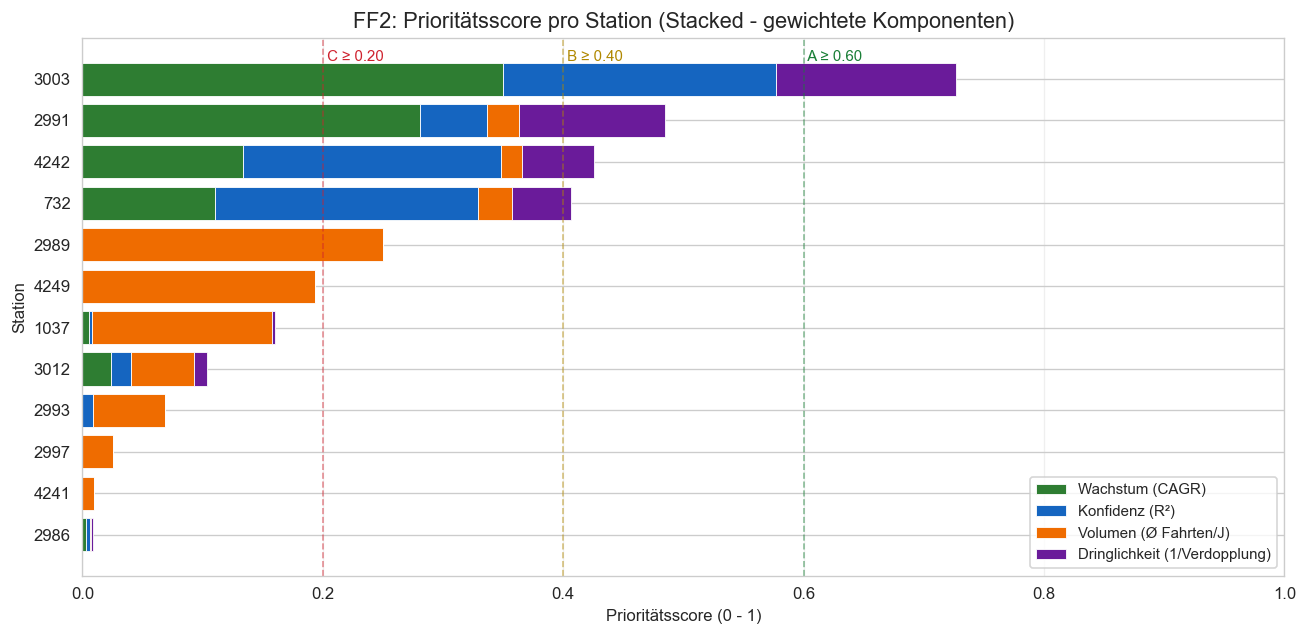

In [30]:
# Visualisierung: Stacked Bar der Score-Komponenten pro Station
fig, ax = plt.subplots(figsize=(11, max(5, len(trends) * 0.45)))

plot_df = trends.sort_values("priority_score", ascending=True).copy()
labels = plot_df["station_id"].astype(str).values

components = [
    ("growth_score",     WEIGHTS["growth"],     "Wachstum (CAGR)",           "#2e7d32"),
    ("confidence_score", WEIGHTS["confidence"], "Konfidenz (R²)",            "#1565c0"),
    ("volume_score",     WEIGHTS["volume"],     "Volumen (Ø Fahrten/J)",     "#ef6c00"),
    ("urgency_score",    WEIGHTS["urgency"],    "Dringlichkeit (1/Verdopplung)", "#6a1b9a"),
]

left = np.zeros(len(plot_df))
for col, weight, label, color in components:
    vals = plot_df[col].values * weight
    ax.barh(labels, vals, left=left, color=color, label=label, edgecolor="white", linewidth=0.5)
    left += vals

# Klassen-Schwellen als vertikale Linien
for thr, lbl, col in [(0.60, "A ≥ 0.60", "#1a7f37"), (0.40, "B ≥ 0.40", "#b08800"), (0.20, "C ≥ 0.20", "#cf222e")]:
    ax.axvline(x=thr, color=col, linestyle="--", alpha=0.5, linewidth=1)
    ax.text(thr, len(plot_df) - 0.3, f" {lbl}", color=col, fontsize=9, va="top")

ax.set_xlabel("Prioritätsscore (0 - 1)")
ax.set_ylabel("Station")
ax.set_title("FF2: Prioritätsscore pro Station (Stacked - gewichtete Komponenten)", fontsize=13)
ax.set_xlim(0, 1)
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()


---
## Schritt 16: Wachstums-Hotspots auf der Zürich-Karte

Jede Zählstelle wird als konzentrische Kreisstruktur dargestellt &#8211; der Radius ist proportional zur Stärke des Wachstumstrends. Die Farbe zeigt die Richtung (grün = Wachstum, rot = Rückgang). Der Popup-Marker zeigt zusätzlich den berechneten Prioritätsscore und die Prioritätsklasse (A bis D).


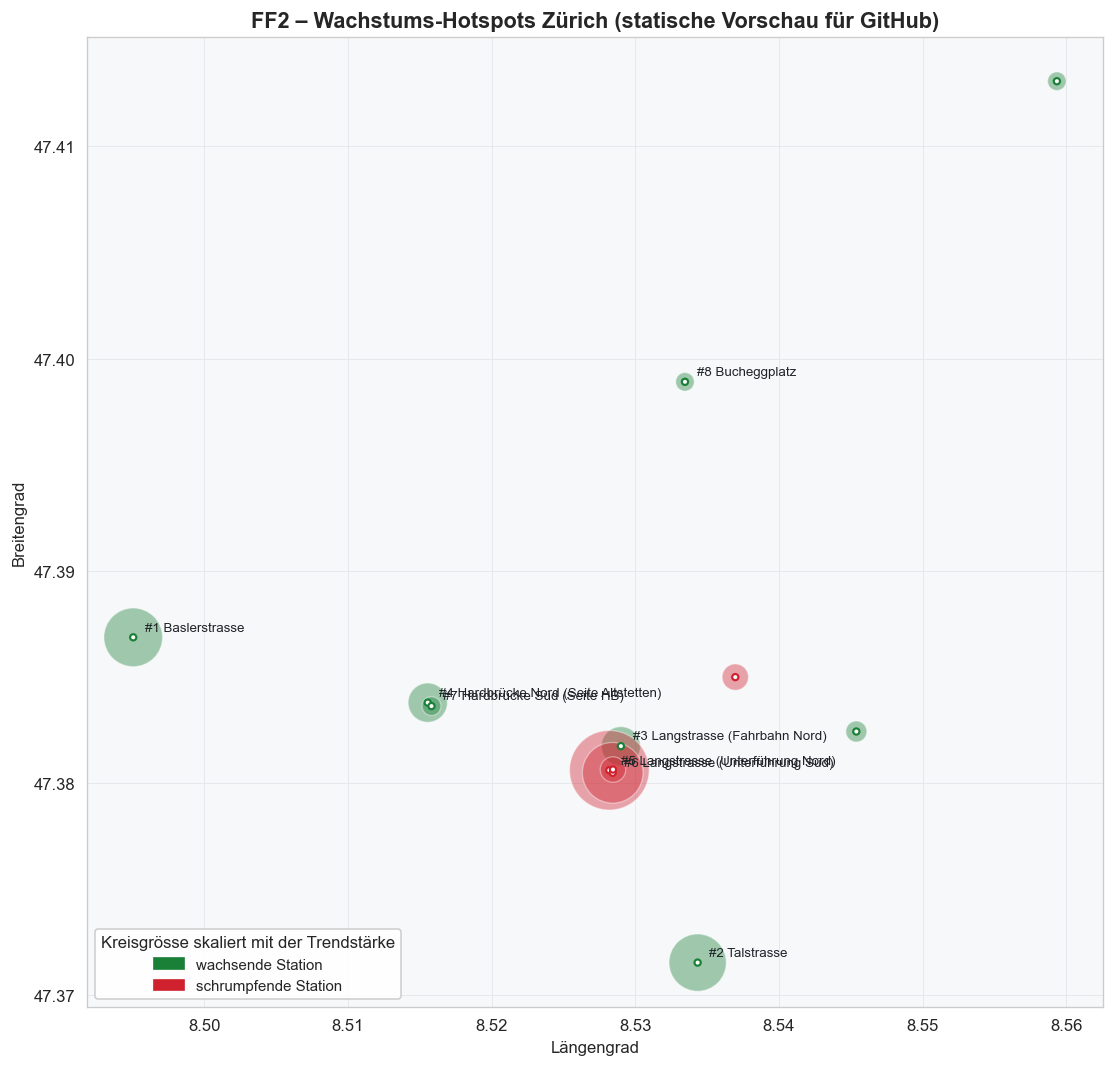

Interaktive Karte gespeichert: ff2_zuerich_map.html (öffnet auch direkt im Browser)


In [31]:
import folium
import base64
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pyproj import Transformer
from IPython.display import HTML, display

# LV95 (Swiss) -> WGS84 (lat/lon)
transformer = Transformer.from_crs("EPSG:2056", "EPSG:4326", always_xy=True)

map_data = trends.merge(
    meta[["station_id", "easting", "northing"] + (["station_name"] if "station_name" in meta.columns else [])],
    on="station_id",
    how="left",
)
map_data["lon"], map_data["lat"] = transformer.transform(
    map_data["easting"].values, map_data["northing"].values
)

# Karte zentriert auf Zürich
center_lat = map_data["lat"].mean()
center_lon = map_data["lon"].mean()

# Radius-Skalierung: stärkster absoluter Trend bekommt MAX_RADIUS_M
max_abs_slope = map_data["slope"].abs().max()
BASE_RADIUS_M = 120
MAX_RADIUS_M  = 900

# =====================================================================
# 1) Interaktive Folium-Karte (live in Jupyter Lab / VSCode / nbviewer)
# =====================================================================
m = folium.Map(location=[center_lat, center_lon], zoom_start=13, tiles="cartodbpositron")

for _, row in map_data.iterrows():
    sid = int(row["station_id"])
    sname = row.get("station_name") or station_name_map.get(sid, "")
    title = f"{sname} (#{sid})" if sname else f"Station {sid}"
    slope = row["slope"]
    cagr  = row["cagr"] * 100 if pd.notnull(row["cagr"]) else 0
    color = "#1a7f37" if slope > 0 else "#cf222e"   # green / red

    radius_m = BASE_RADIUS_M + (abs(slope) / max_abs_slope) * (MAX_RADIUS_M - BASE_RADIUS_M)

    # Radar-Effekt: 3 konzentrische Kreise mit abnehmender Deckkraft
    for mult, opa in [(1.0, 0.35), (1.6, 0.18), (2.3, 0.07)]:
        folium.Circle(
            location=[row["lat"], row["lon"]],
            radius=radius_m * mult,
            color=color, weight=0,
            fill=True, fill_color=color, fill_opacity=opa,
        ).add_to(m)

    # Zentrum-Marker mit Popup
    doubl = f"{row['doubling_years']:.1f}J" if row['doubling_years'] < 100 else "nie"
    popup_html = f"""
    <div style="font-family: Arial; width: 250px;">
        <h4 style="margin:0 0 8px 0; color:{color};">{title}</h4>
        <table style="font-size: 13px; width: 100%;">
            <tr><td><b>Priorität:</b></td><td><b>#{int(row['priority_rank'])} &middot; {row['priority_class']}</b></td></tr>
            <tr><td><b>Score:</b></td><td>{row['priority_score']:.3f}</td></tr>
            <tr><td><b>Trend:</b></td><td>{slope:+,.0f} Fahrten/Jahr</td></tr>
            <tr><td><b>Relativ:</b></td><td>{row['slope_pct']:+.1f}%/Jahr</td></tr>
            <tr><td><b>CAGR:</b></td><td>{cagr:+.1f}%</td></tr>
            <tr><td><b>R&sup2;:</b></td><td>{row['r_squared']:.3f}</td></tr>
            <tr><td><b>Qualit&auml;t:</b></td><td>{row['trend_quality']}</td></tr>
            <tr><td><b>Verdopplung:</b></td><td>{doubl}</td></tr>
            <tr><td><b>&Oslash; Fahrten/J:</b></td><td>{row['mean_annual']:,.0f}</td></tr>
        </table>
    </div>
    """
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=5,
        color=color, weight=2,
        fill=True, fill_color="white", fill_opacity=1,
        popup=folium.Popup(popup_html, max_width=280),
        tooltip=f"#{int(row['priority_rank'])} {title}: Score {row['priority_score']:.2f}",
    ).add_to(m)

legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
     background: white; padding: 14px 16px; border-radius: 8px; border: 1px solid #ddd;
     box-shadow: 0 2px 8px rgba(0,0,0,0.15);
     font-family: Arial; font-size: 13px;">
    <b style="font-size: 14px;">Wachstumstrend</b><br><br>
    <span style="color:#1a7f37; font-size:18px;">&#9679;</span> Wachsende Station<br>
    <span style="color:#cf222e; font-size:18px;">&#9679;</span> Schrumpfende Station<br>
    <i style="color:#666;">Kreisgr&ouml;sse &#8733; St&auml;rke des Trends</i><br>
    <i style="color:#666;">Popup: Priorit&auml;tsrang &amp; Score</i>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# Auch als standalone HTML speichern (zum Öffnen im Browser ausserhalb Jupyter)
m.save("ff2_zuerich_map.html")

# =====================================================================
# 2) Statische Vorschau (PNG) -- Fallback für GitHub
# ---------------------------------------------------------------------
# GitHubs Notebook-Renderer entfernt <iframe>/<script> aus den Outputs,
# sodass die interaktive Folium-Karte dort leer bleibt. Diese statische
# matplotlib-Vorschau überlebt die Bereinigung und rendert überall.
# (Ohne Kartenkacheln -- Stationen als Bubbles, geografisch korrekt skaliert.)
# =====================================================================
fig, ax = plt.subplots(figsize=(10, 9))
slope_abs = map_data["slope"].abs()
bubble_size = 80 + (slope_abs / max_abs_slope) * 2200          # Punktfläche ∝ Trendstärke
bubble_color = np.where(map_data["slope"] > 0, "#1a7f37", "#cf222e")

ax.scatter(map_data["lon"], map_data["lat"], s=bubble_size, c=bubble_color,
           alpha=0.40, edgecolors="white", linewidths=0.8, zorder=2)
ax.scatter(map_data["lon"], map_data["lat"], s=14, c="white",
           edgecolors=bubble_color, linewidths=1.3, zorder=3)

# Top-Prioritäten beschriften
for _, row in map_data.nsmallest(8, "priority_rank").iterrows():
    sid = int(row["station_id"])
    sname = row.get("station_name") or station_name_map.get(sid, f"#{sid}")
    ax.annotate(f"#{int(row['priority_rank'])} {sname}",
                (row["lon"], row["lat"]),
                textcoords="offset points", xytext=(7, 4),
                fontsize=8, color="#1f2328", zorder=4)

# Geografisch korrektes Seitenverhältnis auf Zürichs Breitengrad
ax.set_aspect(1 / np.cos(np.radians(center_lat)))
ax.set_title("FF2 – Wachstums-Hotspots Zürich (statische Vorschau für GitHub)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Längengrad")
ax.set_ylabel("Breitengrad")
ax.set_facecolor("#f6f8fa")
ax.grid(True, color="#e6e8eb", linewidth=0.6, zorder=0)
legend_handles = [
    mpatches.Patch(color="#1a7f37", label="wachsende Station"),
    mpatches.Patch(color="#cf222e", label="schrumpfende Station"),
]
ax.legend(handles=legend_handles, loc="lower left", framealpha=0.9, fontsize=9,
          title="Kreisgrösse skaliert mit der Trendstärke")
fig.tight_layout()
plt.show()

# =====================================================================
# 3) Interaktive Karte als base64-Data-URI-Iframe
# ---------------------------------------------------------------------
# Vorteil: funktioniert ohne "Trust Notebook" und ohne relative Dateipfade,
# rendert in Jupyter Lab / VSCode / nbviewer direkt. Auf GitHub wird der
# iframe entfernt -> dort dient die statische Vorschau (oben) als Fallback.
# Der umschliessende <div> verhindert die IPython-Warnung "Consider using
# IPython.display.IFrame instead" (sie greift nur, wenn der HTML-String mit
# <iframe ... beginnt und mit </iframe> endet).
# =====================================================================
print("Interaktive Karte gespeichert: ff2_zuerich_map.html (öffnet auch direkt im Browser)")
map_html_str = m.get_root().render()
b64 = base64.b64encode(map_html_str.encode("utf-8")).decode("ascii")
display(HTML(
    '<div style="margin-top:8px;">'
    f'<iframe src="data:text/html;base64,{b64}" '
    'width="100%" height="600" style="border:none;"></iframe>'
    '</div>'
))


---
## Schritt 17: Export  -  FF2-Ergebnisse speichern

Wir speichern die Trendanalyse inklusive Prioritätsscore als CSV. Der Export enthält alle Kennzahlen pro Station (Slope, CAGR, R², Volumen, Verdopplungszeit) sowie den berechneten `priority_score`, die Einzelkomponenten und die `priority_class` (A-D). Damit liegt das vollständige FF2-Ergebnis als strukturierte Datei vor und kann für Präsentationen, Dashboards oder als Input für kombinierte Analysen mit weiteren Forschungsfragen verwendet werden.


In [32]:
import os

# Export-Verzeichnis
os.makedirs("../../data/clean", exist_ok=True)

# Trend-Ergebnisse inkl. Prioritätsscore exportieren
export_cols = [
    "priority_rank", "station_id", "station_name", "priority_score", "priority_class",
    "growth_score", "confidence_score", "volume_score", "urgency_score",
    "slope", "slope_pct", "intercept", "r_squared", "p_value",
    "cagr", "doubling_years", "doubles_in_5y", "trend_quality",
    "mean_annual", "first_year_total", "last_year_total", "n_years",
]
trends_sorted = trends.sort_values("priority_rank")
trends_sorted[export_cols].to_csv("../../data/clean/ff2_growth_trends.csv", index=False)

# Jahrestotale exportieren (für spätere Visualisierungen)
yearly[["station_id", "year", "velo_total_sum", "velo_annual", "coverage_pct"]].to_csv(
    "../../data/clean/ff2_yearly_totals.csv", index=False
)

print("Exportiert:")
print(f"  data/clean/ff2_growth_trends.csv  ({len(trends)} Stationen, inkl. Prioritätsscore)")
print(f"  data/clean/ff2_yearly_totals.csv  ({len(yearly)} Station-Jahre)")
print(f"\nSpalten in ff2_growth_trends.csv:")
for col in export_cols:
    print(f"  - {col}")


Exportiert:
  data/clean/ff2_growth_trends.csv  (12 Stationen, inkl. Prioritätsscore)
  data/clean/ff2_yearly_totals.csv  (67 Station-Jahre)

Spalten in ff2_growth_trends.csv:
  - priority_rank
  - station_id
  - station_name
  - priority_score
  - priority_class
  - growth_score
  - confidence_score
  - volume_score
  - urgency_score
  - slope
  - slope_pct
  - intercept
  - r_squared
  - p_value
  - cagr
  - doubling_years
  - doubles_in_5y
  - trend_quality
  - mean_annual
  - first_year_total
  - last_year_total
  - n_years


---
## Schritt 18: Antwort auf die Management-Entscheidungsfrage

> Dieser Schritt entspricht **CPA Step 5 — Make data-driven decisions**: die Übersetzung der vorangegangenen Analyse (Steps 3-4) in eine konkrete Handlungsempfehlung.

**Forschungsfrage FF2:**
> Welche Zählstellen zeigen den stärksten Wachstumstrend (2020-2025)? Bei Fortschreibung des aktuellen Trends: Welche Stationen werden ihr Aufkommen innerhalb von 5 Jahren verdoppeln? Und wo soll die Stadt präventive Kapazitätserweiterung priorisieren?

Die folgende Zelle fasst die Analyse in einer direkten, managementtauglichen Empfehlung zusammen. Sie kombiniert die Konzentrations-Analyse aus Schritt 14 (Ergebnis A vs. B), die Verdopplungs-Prognose aus Schritt 10, und das Priorisierungs-Ranking aus Schritt 15 zu einem klaren Handlungsauftrag.

In [33]:
from IPython.display import HTML, display

# Zahlen fuer das Management-Briefing rekonstruieren
growing_df = trends[trends["slope"] > 0]
shrinking_df = trends[trends["slope"] < 0]

top3_growth_share = 0.0
if len(growing_df) > 0:
    top3_growth_share = (
        growing_df.nlargest(3, "slope")["slope"].sum()
        / growing_df["slope"].sum() * 100
    )

reliable_growth = trends[
    (trends["slope"] > 0)
    & (trends["trend_quality"].isin(["strong", "moderate"]))
].sort_values("priority_score", ascending=False)

doubling_stations = trends[trends["doubles_in_5y"] == True]["station_id"].tolist()

class_counts = trends["priority_class_letter"].value_counts().to_dict()
class_a = trends[trends["priority_class_letter"] == "A"]
class_b = trends[trends["priority_class_letter"] == "B"]

# ---------- Block 1: Konzentrations-Verdikt ---------------------------------
if top3_growth_share > 60:
    verdict_color  = "#1a7f37"
    verdict_bg     = "#e6f4ea"
    verdict_title  = "Ergebnis A: Wachstum ist KONZENTRIERT"
    verdict_text   = (
        f"Die Top-3 wachsenden Stationen vereinen <b>{top3_growth_share:.0f}%</b> "
        "des gesamten positiven Trendvolumens. Eine standortbasierte "
        "Priorisierung ist angemessen (kein flaechendeckender Ausbau)."
    )
else:
    verdict_color  = "#9a6700"
    verdict_bg     = "#fff8e1"
    verdict_title  = "Ergebnis B: Wachstum ist VERTEILT"
    verdict_text   = (
        f"Top-3-Stationen vereinen nur <b>{top3_growth_share:.0f}%</b> des "
        "Wachstums. Netzweite Standards (Breiten, Signalisation) sind wichtiger "
        "als Einzelstandort-Ausbauten."
    )

# ---------- Block 2: Verdopplungsprognose -----------------------------------
if len(doubling_stations) > 0:
    items = []
    for sid in doubling_stations:
        r = trends[trends["station_id"] == sid].iloc[0]
        items.append(
            f"<li><b>{station_label(sid)}</b>: Verdopplung in "
            f"{r['doubling_years']:.1f} Jahren (CAGR {r['cagr']*100:+.1f}%)</li>"
        )
    items_html = "".join(items)
    doubling_html = (
        f"<p style='margin:0 0 6px 0;'>{len(doubling_stations)} Station(en) verdoppeln "
        "ihr Aufkommen voraussichtlich innerhalb von 5 Jahren:</p>"
        f"<ul style='margin:6px 0 0 18px;'>{items_html}</ul>"
    )
    doubling_color = "#9a6700"
    doubling_bg    = "#fff8e1"
else:
    nearest = trends[trends["cagr"] > 0].sort_values("doubling_years").head(1)
    if len(nearest) > 0:
        n = nearest.iloc[0]
        nearest_str = (
            f" Naechste Station: <b>{station_label(n['station_id'])}</b> "
            f"(Verdopplung in {n['doubling_years']:.1f} J)."
        )
    else:
        nearest_str = ""
    doubling_html = (
        "<p style='margin:0;'>Keine Station verdoppelt ihr Aufkommen bei "
        "aktueller Trendfortschreibung innerhalb von 5 Jahren. Akuter "
        "Kapazitaetsnotstand ist unwahrscheinlich, mittelfristige Reserve-"
        "Planung bleibt sinnvoll."
        f"{nearest_str}</p>"
    )
    doubling_color = "#1f6feb"
    doubling_bg    = "#ddf4ff"

# ---------- Block 3: Klassenverteilung --------------------------------------
class_chips_parts = []
for cl, label, col, bg in [
    ("A", "A - sofort handeln",          "#1a7f37", "#e6f4ea"),
    ("B", "B - mittelfristig beobachten","#9a6700", "#fff8e1"),
    ("C", "C - niedrige Prioritaet",     "#8a4b00", "#fde7d3"),
    ("D", "D - keine Massnahme noetig",  "#656d76", "#f0f1f3"),
]:
    n = class_counts.get(cl, 0)
    class_chips_parts.append(
        f'<div style="background:{bg};border-left:4px solid {col};'
        f'padding:8px 12px;border-radius:4px;flex:1;min-width:170px;">'
        f'<div style="font-size:11px;color:#666;text-transform:uppercase;'
        f'letter-spacing:0.5px;">{label}</div>'
        f'<div style="font-size:24px;font-weight:700;color:{col};">{n}</div>'
        f'<div style="font-size:11px;color:#666;">Station(en)</div>'
        f'</div>'
    )
class_chips_html = "".join(class_chips_parts)

# ---------- Block 4: Aktionsliste -------------------------------------------
def _station_card(row, accent, bg):
    cagr_val = row["cagr"]
    cagr_str = f"{cagr_val*100:+.1f}%" if pd.notnull(cagr_val) else "N/A"
    if row["doubling_years"] < 100:
        doubl = f"Verdopplung in {row['doubling_years']:.1f}J"
    else:
        doubl = "keine Verdopplung absehbar"
    sid   = int(row["station_id"])
    sname = row.get("station_name") or station_name_map.get(sid, "")
    title = f"{sname} (#{sid})" if sname else f"Station {sid}"
    rank  = int(row["priority_rank"])
    score = float(row["priority_score"])
    return (
        f'<div style="background:{bg};border-left:4px solid {accent};'
        f'padding:10px 14px;border-radius:4px;margin-bottom:6px;">'
        f'<div style="display:flex;justify-content:space-between;align-items:baseline;">'
        f'<div><b style="font-size:15px;">{title}</b>'
        f' <span style="color:#666;font-size:12px;">Rang #{rank}</span></div>'
        f'<div style="font-family:monospace;color:{accent};font-weight:600;">'
        f'Score {score:.2f}</div></div>'
        f'<div style="font-size:12px;color:#444;margin-top:3px;">'
        f"CAGR {cagr_str} &middot; "
        f"&Oslash; {row['mean_annual']:,.0f} Fahrten/J &middot; "
        f"R&sup2; {row['r_squared']:.2f} &middot; "
        f"{doubl}"
        f'</div></div>'
    )

action_blocks = []
if len(class_a) > 0:
    cards = "".join(_station_card(r, "#1a7f37", "#e6f4ea") for _, r in class_a.iterrows())
    action_blocks.append(
        '<h4 style="margin:14px 0 6px 0;color:#1a7f37;">'
        f'SOFORT - Klasse A ({len(class_a)} Station(en))'
        '<span style="font-weight:400;color:#666;font-size:13px;">'
        ' - Vorprojekt innerhalb 12 Monate</span></h4>'
        f'{cards}'
    )
elif len(reliable_growth) > 0:
    head = reliable_growth.head(3)
    cards = "".join(_station_card(r, "#9a6700", "#fff8e1") for _, r in head.iterrows())
    action_blocks.append(
        '<h4 style="margin:14px 0 6px 0;color:#9a6700;">'
        'BEOBACHTEN (Top-3 belastbar wachsend)'
        '<span style="font-weight:400;color:#666;font-size:13px;">'
        ' - keine Station erreicht Klasse A</span></h4>'
        f'{cards}'
    )

if len(class_b) > 0:
    cards = "".join(_station_card(r, "#9a6700", "#fff8e1") for _, r in class_b.iterrows())
    action_blocks.append(
        '<h4 style="margin:14px 0 6px 0;color:#9a6700;">'
        f'BEOBACHTEN - Klasse B ({len(class_b)} Station(en))'
        '<span style="font-weight:400;color:#666;font-size:13px;">'
        ' - jaehrliche Neu-Auswertung</span></h4>'
        f'{cards}'
    )

if action_blocks:
    actions_html = "".join(action_blocks)
else:
    actions_html = (
        '<p style="color:#cf222e;"><b>Keine Station zeigt einen statistisch '
        'belastbaren positiven Trend.</b></p>'
    )

# ---------- Block 5: Caveats ------------------------------------------------
n_consistent = trends["station_id"].nunique()
caveats = [
    f"Nur {n_consistent} von 46 Stationen sind konsistent genug fuer die "
    "Zeitreihenanalyse (Schritt 2). Neue Stationen ab 2022/2023 fehlen.",
    "Lineare Extrapolation ignoriert Saettigungseffekte und Netzausbau-Schocks.",
    "Kurzer Zeitraum 2020-2025 enthaelt COVID-Effekte (2020/21 teils Ausreisser).",
    "Der Prioritaetsscore ist eine Entscheidungshilfe, kein Automatismus: "
    "lokale Faktoren (Unfallstatistik, Schulwege, Bauprojekte) muessen "
    "ergaenzt werden.",
]
caveats_html = (
    '<ul style="margin:6px 0 0 18px;color:#555;font-size:12px;">'
    + "".join(f"<li>{c}</li>" for c in caveats)
    + '</ul>'
)

# ---------- Kurzantwort -----------------------------------------------------
if len(class_a) > 0:
    short_answer = "Prioritaet auf " + ", ".join(
        station_label(s) for s in class_a["station_id"].head(3)
    ) + "."
elif len(reliable_growth) > 0:
    short_answer = "Keine Station in Klasse A. Belastbar wachsend: " + ", ".join(
        station_label(s) for s in reliable_growth["station_id"].head(3)
    ) + "."
else:
    short_answer = "Kein statistisch belastbarer Handlungsauftrag - netzweite Standards pruefen."

# ---------- Gesamt-HTML -----------------------------------------------------
html = (
    '<div style="font-family:-apple-system,Segoe UI,Roboto,Helvetica,Arial,sans-serif;'
    'max-width:900px;margin-top:10px;color:#1f2328;line-height:1.45;">'

    '<div style="background:linear-gradient(135deg,#1f6feb 0%,#0969da 100%);'
    'color:#fff;padding:18px 22px;border-radius:8px 8px 0 0;">'
    '<div style="font-size:11px;opacity:0.85;letter-spacing:1px;text-transform:uppercase;">'
    'FF2 - Management-Briefing</div>'
    '<div style="font-size:22px;font-weight:700;margin-top:4px;">'
    'Praeventive Kapazitaetserweiterung</div>'
    '</div>'

    '<div style="border:1px solid #d0d7de;border-top:none;padding:18px 22px;'
    'border-radius:0 0 8px 8px;background:#fff;">'

    '<h3 style="margin:0 0 6px 0;font-size:15px;color:#1f2328;">'
    '1 &middot; Befund: Konzentration des Wachstums</h3>'
    f'<div style="background:{verdict_bg};border-left:4px solid {verdict_color};'
    'padding:10px 14px;border-radius:4px;margin-bottom:18px;">'
    f'<div style="font-weight:600;color:{verdict_color};margin-bottom:4px;">'
    f'{verdict_title}</div>'
    f'<div style="font-size:13px;">{verdict_text}</div></div>'

    '<h3 style="margin:18px 0 6px 0;font-size:15px;color:#1f2328;">'
    '2 &middot; Verdopplungs-Prognose (5 Jahre, lineare CAGR-Extrapolation)</h3>'
    f'<div style="background:{doubling_bg};border-left:4px solid {doubling_color};'
    'padding:10px 14px;border-radius:4px;margin-bottom:18px;font-size:13px;">'
    f'{doubling_html}</div>'

    '<h3 style="margin:18px 0 6px 0;font-size:15px;color:#1f2328;">'
    '3 &middot; Verteilung der Prioritaetsklassen</h3>'
    '<div style="display:flex;gap:8px;flex-wrap:wrap;margin-bottom:18px;">'
    f'{class_chips_html}</div>'

    '<h3 style="margin:18px 0 6px 0;font-size:15px;color:#1f2328;">'
    '4 &middot; Empfohlener Massnahmenkatalog</h3>'
    f'{actions_html}'

    '<h3 style="margin:24px 0 6px 0;font-size:15px;color:#1f2328;">'
    '5 &middot; Einschraenkungen</h3>'
    f'{caveats_html}'

    '<div style="margin-top:20px;padding:14px 18px;background:#f6f8fa;'
    'border-left:4px solid #1f2328;border-radius:4px;">'
    '<div style="font-size:11px;color:#656d76;text-transform:uppercase;'
    'letter-spacing:0.5px;">Kurzantwort</div>'
    f'<div style="font-size:16px;font-weight:600;margin-top:3px;">{short_answer}</div>'
    '</div>'

    '</div></div>'
)

display(HTML(html))


---
## Zusammenfassung der Analyse-Schritte

| Schritt | Was | Warum | Auswirkung |
|---------|-----|-------|------------|
| 1. Daten laden | Parquet + Metadaten aus NB02 | Bereinigte Ausgangsdaten verwenden |  -  |
| 2. Konsistente Stationen | Filter auf `is_consistent == True` | Nur Stationen mit Daten über alle Jahre → fairer Vergleich | Reduziert Stationsanzahl |
| 3. Sensor-Ausfälle | Entferne `is_sensor_failure` / NaN | Keine falschen Nullen in Jahressummen | Entfernt fehlerhafte Messungen |
| 4. Abdeckung prüfen | Coverage % pro Station-Jahr | Transparenz über Datenqualität | Identifiziert lückenhafte Jahre |
| 5. Annualisierung | `raw_sum / coverage` für partielle Jahre | 2025 wäre sonst nicht vergleichbar | Ermöglicht Vergleich trotz Lücken |
| 6. Saisonalitäts-Check | Verzerrung durch Wintermonate prüfen | Einfache Annualisierung unterschätzt bei Winterdaten | Entscheidung: 2025 ein-/ausschliessen |
| 7. Finale Totale | Zusammenführung der bereinigten Werte | Saubere Basis für Regression |  -  |
| 8. YoY-Raten | Jährliche Wachstumsraten | Erstes Trendbild |  -  |
| 9. Lineare Regression | Slope, R², p-value pro Station | Statistisch fundierter Trend | Kern der Analyse |
| 10. CAGR | Zusammengesetztes Wachstum | Verdopplungszeit berechnen | Beantwortet Teilfrage "Verdopplung in 5 J?" |
| 11. Visualisierung | Trendlinien + Extrapolation | Kommunikation der Ergebnisse |  -  |
| 12. Ranking | Absolute + relative Balkendiagramme | Priorisierung der Stationen |  -  |
| 13. Signifikanzfilter | Klassifikation stark/moderat/schwach | Nur belastbare Trends für Entscheidungen | Filtert Rauschen |
| 14. CPA-Entscheid | Konzentrations-Analyse | Ergebnis A vs. B bestimmen | Flächendeckend oder standortbasiert? |
| 15. Prioritätsscore | Gewichteter Composite (Wachstum, Konfidenz, Volumen, Dringlichkeit) | Eindeutige Rangliste für Investitionsentscheidungen | Kern-Output der FF2 |
| 16. Zürich-Karte | Geografische Darstellung + Popup | Räumliche Verteilung verständlich machen |  -  |
| 17. Export | CSVs inkl. Prioritätsscore | Weiterverwendung ausserhalb des Notebooks |  -  |
| 18. Management-Antwort | Direkte Handlungsempfehlung | Übersetzt Analyse in Entscheidung | Liefert konkrete Station-Priorität und Caveats |
